# NIFTY 50 Heston Calibration V6, Working Calibrated Notebook

This notebook rebuilds the Heston calibration pipeline from a clean kernel and executes it end-to-end.

**Research question:** Does the parameterization of the Heston stochastic-volatility model remain stable across Indian option-expiry structures and market-regime conditions?

**Current calibration slice:** NIFTY 50 options on **1 January 2026**, using the frozen maturity, moneyness, liquidity and no-arbitrage filters in the supplied workbook.

**Important implementation choices**
- Heston Fourier engine follows the verified Phase-1 repository formulation.
- Calls are priced directly. Puts are obtained by put-call parity.
- Short-dated options use adaptive Fourier upper bounds.
- Market IV and model IV are obtained with Black-Scholes inversion.
- Calibration objective is vega-weighted squared IV error.
- A 40-observation CE/PE-balanced subset is used for computationally controlled global/local search.
- Final candidates are re-evaluated on the full January universe.
- The historical 388-row V5.1 universe is **not silently forced**. Under this V6 engine and IV solver, all 449 January observations have finite model IVs and form the current calibration universe.


In [1]:
# ============================================================
# 1. ENVIRONMENT AND PATHS
# ============================================================

import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.optimize import brentq, differential_evolution, minimize
from scipy.stats import norm

warnings.filterwarnings("ignore")

# Works both in /mnt/data and when the notebook is moved beside the workbook.
candidates = [
    Path("NIFTY_Heston_Calibration_Master_V2_2026.xlsx"),
    Path("/mnt/data/NIFTY_Heston_Calibration_Master_V2_2026.xlsx")
]

WORKBOOK = next((p for p in candidates if p.exists()), None)

if WORKBOOK is None:
    raise FileNotFoundError(
        "NIFTY_Heston_Calibration_Master_V2_2026.xlsx was not found."
    )

print("Working directory:", Path.cwd())
print("Workbook:", WORKBOOK.resolve())


Working directory: /Users/shakthivel2211gmail.com/Documents/NIFTY DATA
Workbook: /Users/shakthivel2211gmail.com/Documents/NIFTY DATA/NIFTY_Heston_Calibration_Master_V2_2026.xlsx


In [2]:
# ============================================================
# 2. LOAD DATA AND REAPPLY FROZEN JANUARY FILTERS
# ============================================================

xls = pd.ExcelFile(WORKBOOK)
print("Sheets:", xls.sheet_names)

raw = pd.read_excel(
    WORKBOOK,
    sheet_name="Calibration_Options"
)

rename_map = {
    "Option type": "option_type",
    "Strike Price": "K",
    "Underlying Value": "S",
    "Days_to_Expiry": "DTE",
    "T_Years_365": "T",
    "Risk_Free_Rate": "r",
    "Market_Price": "market_price",
    "No. of contracts": "contracts",
    "Open Int": "OI",
    "Log_Moneyness_lnK_overS": "log_moneyness",
    "No_Arbitrage_Pass": "no_arb",
    "Date": "date",
    "Expiry": "expiry"
}

cal = raw.rename(
    columns={k: v for k, v in rename_map.items() if k in raw.columns}
).copy()

cal["date"] = pd.to_datetime(cal["date"])
cal["option_type"] = (
    cal["option_type"].astype(str).str.upper().str.strip()
)

for c in ["S", "K", "T", "r", "market_price", "DTE", "log_moneyness",
          "contracts", "OI"]:
    cal[c] = pd.to_numeric(cal[c], errors="coerce")

liquidity_pass = (
    (cal["contracts"] >= 100) |
    (cal["OI"] >= 1000)
)

base = (
    cal["date"].eq(pd.Timestamp("2026-01-01"))
    & cal["DTE"].between(5, 45, inclusive="both")
    & cal["log_moneyness"].abs().le(0.15)
    & liquidity_pass
    & cal["no_arb"].eq(True)
    & cal["market_price"].gt(0)
)

jan = cal.loc[base].copy().reset_index(drop=True)

print("January filtered universe:", len(jan))
print(jan["option_type"].value_counts())
assert len(jan) == 449


Sheets: ['Calibration_Options', 'Sample_Audit', 'Risk_Free_Rates', 'Methodology', 'Expiry_Classification', 'Eligible_Only']
January filtered universe: 449
option_type
CE    237
PE    212
Name: count, dtype: int64


## 3. Black-Scholes IV and Vega

Market IV is obtained from the observed option market price. The inversion requires the observed price to lie strictly inside the Black-Scholes no-arbitrage interval. Vega is evaluated at the market IV and used to construct normalized calibration weights.


In [3]:
# ============================================================
# 3. BLACK-SCHOLES PRICE, IV AND VEGA
# ============================================================

def bs_price(S, K, T, r, sigma, option_type):
    if not all(np.isfinite(x) for x in [S, K, T, r, sigma]):
        return np.nan
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call = (
        S * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

    if option_type == "CE":
        return float(call)

    if option_type == "PE":
        return float(call - S + K * np.exp(-r * T))

    return np.nan


def bs_iv(price, S, K, T, r, option_type):
    try:
        price, S, K, T, r = map(float, [price, S, K, T, r])
        option_type = str(option_type).upper().strip()
    except Exception:
        return np.nan

    if not all(np.isfinite(x) for x in [price, S, K, T, r]):
        return np.nan
    if price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    if option_type == "CE":
        intrinsic = max(S - K * np.exp(-r * T), 0.0)
        upper = S
    elif option_type == "PE":
        intrinsic = max(K * np.exp(-r * T) - S, 0.0)
        upper = K * np.exp(-r * T)
    else:
        return np.nan

    tol = 1e-10
    if price <= intrinsic + tol or price >= upper - tol:
        return np.nan

    def f(sigma):
        return bs_price(S, K, T, r, sigma, option_type) - price

    try:
        lo, hi = 1e-8, 5.0
        flo, fhi = f(lo), f(hi)
        if not np.isfinite(flo) or not np.isfinite(fhi) or flo * fhi > 0:
            return np.nan

        iv = brentq(f, lo, hi, xtol=1e-10, rtol=1e-10, maxiter=200)
        return float(iv) if np.isfinite(iv) else np.nan
    except Exception:
        return np.nan


def bs_vega(S, K, T, r, sigma):
    if not all(np.isfinite(x) for x in [S, K, T, r, sigma]):
        return np.nan
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return float(S * norm.pdf(d1) * np.sqrt(T))


jan["market_iv"] = jan.apply(
    lambda row: bs_iv(
        row["market_price"], row["S"], row["K"], row["T"],
        row["r"], row["option_type"]
    ),
    axis=1
)

jan["vega"] = jan.apply(
    lambda row: bs_vega(
        row["S"], row["K"], row["T"], row["r"], row["market_iv"]
    ) if np.isfinite(row["market_iv"]) else np.nan,
    axis=1
)

market_iv_valid = jan.loc[
    jan["market_iv"].notna()
    & np.isfinite(jan["market_iv"])
    & jan["vega"].notna()
    & np.isfinite(jan["vega"])
    & jan["vega"].gt(0)
].copy().reset_index(drop=True)

print("Finite market IV:", len(market_iv_valid))
print("CE / PE:", (market_iv_valid["option_type"] == "CE").sum(),
      "/", (market_iv_valid["option_type"] == "PE").sum())
print(market_iv_valid["market_iv"].describe())

assert len(market_iv_valid) == 449


Finite market IV: 449
CE / PE: 237 / 212
count    449.000000
mean       0.113783
std        0.048239
min        0.035390
25%        0.080804
50%        0.099944
75%        0.132358
max        0.342040
Name: market_iv, dtype: float64


## 4. Verified Heston Fourier engine

The implementation below preserves the verified Phase-1 formulation. The calibration parameter order is `[v0, kappa, theta, xi, rho]`, while the engine internally receives `v0, theta, kappa, xi, rho`.

The original engine does not include dividends, so the supplied historical risk-free rate is used directly, consistent with the verified benchmark setup.


In [4]:
# ============================================================
# 4. HESTON FOURIER ENGINE
# ============================================================

def heston_auxiliary(phi, j, kappa_star, zeta, rho):
    if j == 1:
        u = 0.5
        b = kappa_star - rho * zeta
    elif j == 2:
        u = -0.5
        b = kappa_star
    else:
        raise ValueError("j must be 1 or 2")

    gamma = 0.5 * zeta**2
    alpha = 1j * u * phi - 0.5 * phi**2
    beta = b - rho * zeta * 1j * phi
    return u, b, gamma, alpha, beta


def heston_riccati(phi, j, kappa_star, zeta, rho):
    _, b, gamma, alpha, beta = heston_auxiliary(
        phi, j, kappa_star, zeta, rho
    )

    d = np.sqrt(beta**2 - 4 * gamma * alpha)
    if np.real(d) < 0:
        d = -d

    r_plus = (beta + d) / zeta**2
    r_minus = (beta - d) / zeta**2
    g = r_minus / r_plus

    return d, r_plus, r_minus, g


def heston_CD(phi, j, tau, r, theta, kappa, xi, rho):
    d, r_plus, r_minus, g = heston_riccati(
        phi, j, kappa, xi, rho
    )

    exp_term = np.exp(-d * tau)

    D = r_minus * (1 - exp_term) / (1 - g * exp_term)

    C = (
        (1j * r * phi / theta) * tau
        + kappa * (
            r_minus * tau
            - (2 / xi**2)
            * np.log((1 - g * exp_term) / (1 - g))
        )
    )

    return C, D


def heston_integrand(phi, j, S0, K, tau, r, v0, theta, kappa, xi, rho):
    C, D = heston_CD(
        phi, j, tau, r, theta, kappa, xi, rho
    )

    x = np.log(S0)

    numerator = np.exp(
        C * theta
        + D * v0
        + 1j * phi * x
        - 1j * phi * np.log(K)
    )

    return np.real(numerator / (1j * phi))


def heston_probability(j, S0, K, tau, r, v0, theta, kappa, xi, rho,
                       upper_bound=100):
    integral, error = quad(
        heston_integrand,
        1e-8,
        upper_bound,
        args=(j, S0, K, tau, r, v0, theta, kappa, xi, rho),
        limit=300,
        epsabs=1e-10,
        epsrel=1e-10
    )

    return 0.5 + integral / np.pi, error


def heston_call_price(S0, K, T, r, v0, theta, kappa, xi, rho, upper_bound=100):
    P1, e1 = heston_probability(
        1, S0, K, T, r, v0, theta, kappa, xi, rho, upper_bound
    )
    P2, e2 = heston_probability(
        2, S0, K, T, r, v0, theta, kappa, xi, rho, upper_bound
    )

    return (
        float(S0 * P1 - K * np.exp(-r * T) * P2),
        P1, P2, e1, e2
    )


# Mandatory benchmark
benchmark_price = heston_call_price(
    100, 100, 1, 0.04,
    0.04, 0.04, 2.0, 0.30, -0.70,
    upper_bound=100
)[0]

print("Phase-1 benchmark price:", benchmark_price)
print("Expected benchmark:      9.812195011257")
print("Absolute error:",
      abs(benchmark_price - 9.812195011257))

assert abs(benchmark_price - 9.812195011257) < 1e-8


Phase-1 benchmark price: 9.81219501125711
Expected benchmark:      9.812195011257
Absolute error: 1.1013412404281553e-13


## 5. Adaptive Fourier pricing

Short-dated NIFTY wings require a substantially larger integration upper bound than the textbook benchmark. The adaptive routine therefore checks successive bounds up to 5000.

For calibration speed, a fixed `U=2000` is used as the numerical calibration engine after convergence testing. The final selected parameters are then independently re-priced with the adaptive grid and a practical `1e-5` absolute/relative convergence criterion.


In [5]:
# ============================================================
# 5. ADAPTIVE PRICER
# ============================================================

FOURIER_GRID = [
    100, 150, 200, 300, 400, 500, 750, 1000,
    1250, 1500, 2000, 2500, 3000, 4000, 5000
]

CALIBRATION_U = 2000
FINAL_ABS_TOL = 1e-5
FINAL_REL_TOL = 1e-5


def adaptive_heston_call(S0, K, T, r, v0, theta, kappa, xi, rho,
                         abs_tol=FINAL_ABS_TOL, rel_tol=FINAL_REL_TOL):
    prev = None
    last = None

    for U in FOURIER_GRID:
        try:
            price, P1, P2, e1, e2 = heston_call_price(
                S0, K, T, r, v0, theta, kappa, xi, rho,
                upper_bound=U
            )

            if not np.isfinite(price):
                continue

            last = (price, U)

            if prev is not None:
                change = abs(price - prev)
                scale = max(abs(price), abs(prev), 1.0)

                if change <= abs_tol + rel_tol * scale:
                    return {
                        "call_price": float(price),
                        "U": int(U),
                        "converged": True
                    }

            prev = price

        except Exception:
            continue

    return {
        "call_price": float(last[0]) if last is not None else np.nan,
        "U": int(last[1]) if last is not None else FOURIER_GRID[-1],
        "converged": False
    }


def heston_option_price(S0, K, T, r, option_type,
                        v0, theta, kappa, xi, rho,
                        upper_bound=CALIBRATION_U):
    C, P1, P2, e1, e2 = heston_call_price(
        S0, K, T, r, v0, theta, kappa, xi, rho,
        upper_bound=upper_bound
    )

    option_type = str(option_type).upper()

    if option_type == "CE":
        price = C
    elif option_type == "PE":
        price = C - S0 + K * np.exp(-r * T)
    else:
        raise ValueError(f"Unknown option type: {option_type}")

    return {
        "call_price": float(C),
        "option_price": float(price),
        "P1": float(P1),
        "P2": float(P2)
    }


## 6. Calibration objective

The objective is

`min Σ w_i (IV_market,i - IV_Heston,i)^2`

with `w_i = Vega_i / Σ Vega_i`.

The calibration search uses a deterministic 40-observation subset with equal CE/PE representation. This is a computational device for the nonlinear search, not a change to the final reporting universe. Every candidate is subsequently evaluated on all 449 observations.


In [6]:
# ============================================================
# 6. FIXED-U CALIBRATION OBJECTIVE
# ============================================================

S_arr = market_iv_valid["S"].to_numpy(float)
K_arr = market_iv_valid["K"].to_numpy(float)
T_arr = market_iv_valid["T"].to_numpy(float)
r_arr = market_iv_valid["r"].to_numpy(float)
mkt_iv_arr = market_iv_valid["market_iv"].to_numpy(float)
vega_arr = market_iv_valid["vega"].to_numpy(float)
opt_arr = market_iv_valid["option_type"].astype(str).str.upper().to_numpy()

N = len(S_arr)
full_idx = np.arange(N)

weights_full = vega_arr / vega_arr.sum()

bounds = [
    (0.0001, 0.25),
    (0.01, 20.0),
    (0.0001, 0.25),
    (0.01, 5.0),
    (-0.999, 0.999)
]


def calibration_objective(params, indices, return_details=False):
    params = np.asarray(params, dtype=float)

    if params.shape != (5,) or not np.isfinite(params).all():
        return 1e6

    v0, kappa, theta, xi, rho = params

    if not (
        0.0001 <= v0 <= 0.25
        and 0.01 <= kappa <= 20.0
        and 0.0001 <= theta <= 0.25
        and 0.01 <= xi <= 5.0
        and -0.999 <= rho <= 0.999
    ):
        return 1e6

    residuals = []
    weights = []

    for i in indices:
        try:
            result = heston_option_price(
                S_arr[i], K_arr[i], T_arr[i], r_arr[i],
                opt_arr[i], v0, theta, kappa, xi, rho,
                upper_bound=CALIBRATION_U
            )

            model_iv = bs_iv(
                result["option_price"],
                S_arr[i], K_arr[i], T_arr[i], r_arr[i],
                opt_arr[i]
            )

            if np.isfinite(model_iv):
                residuals.append(mkt_iv_arr[i] - model_iv)
                weights.append(vega_arr[i])

        except Exception:
            continue

    if not residuals:
        return 1e6

    residuals = np.asarray(residuals, float)
    weights = np.asarray(weights, float)
    weights /= weights.sum()

    objective = float(np.sum(weights * residuals**2))

    if return_details:
        return {
            "objective": objective,
            "iv_rmse": float(np.sqrt(np.mean(residuals**2))),
            "iv_mae": float(np.mean(np.abs(residuals))),
            "n_used": len(residuals),
            "residuals": residuals
        }

    return objective


benchmark_params = np.array([0.04, 2.0, 0.04, 0.30, -0.70])

benchmark_full = calibration_objective(
    benchmark_params, full_idx, return_details=True
)

print("Benchmark full objective:", benchmark_full["objective"])
print("Benchmark IV RMSE:", benchmark_full["iv_rmse"])
print("Benchmark IV MAE:", benchmark_full["iv_mae"])
assert abs(benchmark_full["objective"] - 0.0119038731436) < 1e-7


Benchmark full objective: 0.011903873143635403
Benchmark IV RMSE: 0.09856761263580725
Benchmark IV MAE: 0.09204290691378313


In [7]:
# ============================================================
# 7. GLOBAL SEARCH: DIFFERENTIAL EVOLUTION
# ============================================================

rng = np.random.default_rng(42)

ce_idx = np.where(opt_arr == "CE")[0]
pe_idx = np.where(opt_arr == "PE")[0]

pilot_idx = np.concatenate([
    rng.choice(ce_idx, size=min(20, len(ce_idx)), replace=False),
    rng.choice(pe_idx, size=min(20, len(pe_idx)), replace=False)
])

print("Pilot observations:", len(pilot_idx))
print("CE / PE:", np.sum(opt_arr[pilot_idx] == "CE"),
      "/", np.sum(opt_arr[pilot_idx] == "PE"))

t0 = time.perf_counter()

de_result = differential_evolution(
    lambda p: calibration_objective(p, pilot_idx),
    bounds=bounds,
    seed=42,
    popsize=3,
    maxiter=6,
    polish=False,
    workers=1,
    updating="immediate"
)

de_runtime = time.perf_counter() - t0

DE_PARAMS = np.asarray(de_result.x, float)
DE_SUBSET_OBJECTIVE = float(de_result.fun)
DE_FULL = calibration_objective(
    DE_PARAMS, full_idx, return_details=True
)

print(); print("DE result")
print("Success:", de_result.success)
print("Evaluations:", de_result.nfev)
print("Runtime:", f"{de_runtime:.2f}s")
print("Parameters:", DE_PARAMS)
print("Subset objective:", DE_SUBSET_OBJECTIVE)
print("Full objective:", DE_FULL["objective"])
print("Full RMSE:", DE_FULL["iv_rmse"])
print("Full MAE:", DE_FULL["iv_mae"])


Pilot observations: 40
CE / PE: 20 / 20

DE result
Success: False
Evaluations: 105
Runtime: 19.90s
Parameters: [ 8.54639188e-04  8.93743594e+00  6.19486520e-02  3.94594409e+00
 -6.30597455e-02]
Subset objective: 0.00030177191059381167
Full objective: 0.00040896475610365917
Full RMSE: 0.02776739062027331
Full MAE: 0.02202956351140522


In [8]:
# ============================================================
# 8. LOCAL SEARCH: POWELL
# ============================================================

# Powell is deliberately run from the benchmark point as an
# independent local-search start. The final candidate is selected
# mechanically by the lowest full-sample calibration objective.

t0 = time.perf_counter()

powell_result = minimize(
    lambda p: calibration_objective(p, pilot_idx),
    benchmark_params,
    method="Powell",
    bounds=bounds,
    options={
        "maxiter": 3,
        "xtol": 0.02,
        "ftol": 0.002,
        "disp": False
    }
)

powell_runtime = time.perf_counter() - t0

POWELL_PARAMS = np.asarray(powell_result.x, float)
POWELL_SUBSET_OBJECTIVE = float(powell_result.fun)

POWELL_FULL = calibration_objective(
    POWELL_PARAMS, full_idx, return_details=True
)

print(); print("Powell result")
print("Success:", powell_result.success)
print("Iterations:", powell_result.nit)
print("Evaluations:", powell_result.nfev)
print("Runtime:", f"{powell_runtime:.2f}s")
print("Parameters:", POWELL_PARAMS)
print("Subset objective:", POWELL_SUBSET_OBJECTIVE)
print("Full objective:", POWELL_FULL["objective"])
print("Full RMSE:", POWELL_FULL["iv_rmse"])
print("Full MAE:", POWELL_FULL["iv_mae"])



Powell result
Success: False
Iterations: 3
Evaluations: 152
Runtime: 27.14s
Parameters: [ 9.94847071e-04  6.43301324e+00  5.86005600e-02  1.80053985e+00
 -3.55846824e-01]
Subset objective: 0.00022983230594644154
Full objective: 0.0003363852950092547
Full RMSE: 0.027583717853000574
Full MAE: 0.019311017167088714


In [9]:
# ============================================================
# 9. FINAL CANDIDATE SELECTION
# ============================================================

candidates = pd.DataFrame([
    {
        "method": "Differential Evolution",
        "subset_objective": DE_SUBSET_OBJECTIVE,
        "full_objective": DE_FULL["objective"],
        "iv_rmse": DE_FULL["iv_rmse"],
        "iv_mae": DE_FULL["iv_mae"],
        "v0": DE_PARAMS[0],
        "kappa": DE_PARAMS[1],
        "theta": DE_PARAMS[2],
        "xi": DE_PARAMS[3],
        "rho": DE_PARAMS[4],
    },
    {
        "method": "Powell",
        "subset_objective": POWELL_SUBSET_OBJECTIVE,
        "full_objective": POWELL_FULL["objective"],
        "iv_rmse": POWELL_FULL["iv_rmse"],
        "iv_mae": POWELL_FULL["iv_mae"],
        "v0": POWELL_PARAMS[0],
        "kappa": POWELL_PARAMS[1],
        "theta": POWELL_PARAMS[2],
        "xi": POWELL_PARAMS[3],
        "rho": POWELL_PARAMS[4],
    }
])

display(candidates.sort_values("full_objective"))

best = candidates.sort_values("full_objective").iloc[0]

FINAL_PARAMS = np.array([
    best["v0"], best["kappa"], best["theta"],
    best["xi"], best["rho"]
], dtype=float)

FINAL_FIXED = calibration_objective(
    FINAL_PARAMS, full_idx, return_details=True
)

FINAL_FELLER_LHS = 2 * FINAL_PARAMS[1] * FINAL_PARAMS[2]
FINAL_FELLER_RHS = FINAL_PARAMS[3] ** 2

print(); print("FINAL CALIBRATION PARAMETERS")
for name, value in zip(
    ["v0", "kappa", "theta", "xi", "rho"], FINAL_PARAMS
):
    print(f"{name:<8}: {value:.10f}")

print(); print("Final fixed-U objective:", FINAL_FIXED["objective"])
print("Final IV RMSE:", FINAL_FIXED["iv_rmse"])
print("Final IV MAE:", FINAL_FIXED["iv_mae"])
print("Rows:", FINAL_FIXED["n_used"])
print("Feller LHS:", FINAL_FELLER_LHS)
print("Feller RHS:", FINAL_FELLER_RHS)
print("Feller satisfied:", FINAL_FELLER_LHS >= FINAL_FELLER_RHS)


,method,subset_objective,full_objective,iv_rmse,iv_mae,v0,kappa,theta,xi,rho
1,Powell,0.000230,0.000336,0.027584,0.019311,0.000995,6.433013,0.058601,1.800540,-0.355847
0,Differential Evolution,0.000302,0.000409,0.027767,0.022030,0.000855,8.937436,0.061949,3.945944,-0.063060



FINAL CALIBRATION PARAMETERS
v0      : 0.0009948471
kappa   : 6.4330132393
theta   : 0.0586005600
xi      : 1.8005398524
rho     : -0.3558468241

Final fixed-U objective: 0.0003363852950092547
Final IV RMSE: 0.027583717853000574
Final IV MAE: 0.019311017167088714
Rows: 441
Feller LHS: 0.7539563565653687
Feller RHS: 3.2419437599067944
Feller satisfied: False


## 10. Independent adaptive Fourier validation

The selected parameters are now priced again without the fixed calibration bound. The adaptive routine increases the Fourier integration bound until successive prices satisfy the practical numerical convergence tolerance.

This is the validation layer used for the final reported residuals and convergence diagnostics.


In [10]:
# ============================================================
# 10. FINAL ADAPTIVE VALIDATION
# ============================================================

def adaptive_option_price(S, K, T, r, option_type, params):
    v0, kappa, theta, xi, rho = params

    out = adaptive_heston_call(
        S, K, T, r, v0, theta, kappa, xi, rho,
        abs_tol=FINAL_ABS_TOL,
        rel_tol=FINAL_REL_TOL
    )

    C = out["call_price"]

    if str(option_type).upper() == "CE":
        price = C
    else:
        price = C - S + K * np.exp(-r * T)

    return float(price), int(out["U"]), bool(out["converged"])


validation_rows = []

t0 = time.perf_counter()

for i, row in market_iv_valid.iterrows():

    price, U, converged = adaptive_option_price(
        float(row["S"]),
        float(row["K"]),
        float(row["T"]),
        float(row["r"]),
        row["option_type"],
        FINAL_PARAMS
    )

    model_iv = bs_iv(
        price,
        float(row["S"]),
        float(row["K"]),
        float(row["T"]),
        float(row["r"]),
        row["option_type"]
    )

    if np.isfinite(model_iv):
        validation_rows.append({
            "source_index": i,
            "option_type": row["option_type"],
            "S": float(row["S"]),
            "K": float(row["K"]),
            "T": float(row["T"]),
            "DTE": float(row["DTE"]),
            "market_iv": float(row["market_iv"]),
            "model_price": price,
            "model_iv": float(model_iv),
            "residual": float(row["market_iv"] - model_iv),
            "abs_residual": float(abs(row["market_iv"] - model_iv)),
            "log_moneyness": float(row["log_moneyness"]),
            "selected_U": U,
            "fourier_converged": converged,
            "vega": float(row["vega"])
        })

validation_runtime = time.perf_counter() - t0

final_obs = pd.DataFrame(validation_rows)

weights = final_obs["vega"].to_numpy(float)
weights /= weights.sum()

FINAL_ADAPTIVE_OBJECTIVE = float(
    np.sum(weights * final_obs["residual"].to_numpy(float)**2)
)

FINAL_ADAPTIVE_RMSE = float(
    np.sqrt(np.mean(final_obs["residual"]**2))
)

FINAL_ADAPTIVE_MAE = float(
    np.mean(np.abs(final_obs["residual"]))
)

print("Adaptive validation runtime:", f"{validation_runtime:.2f}s")
print("Rows validated:", len(final_obs))
print("Fourier converged:", int(final_obs["fourier_converged"].sum()))
print("Convergence rate:",
      f"{100 * final_obs['fourier_converged'].mean():.2f}%")
print("Objective:", FINAL_ADAPTIVE_OBJECTIVE)
print("IV RMSE:", FINAL_ADAPTIVE_RMSE)
print("IV MAE:", FINAL_ADAPTIVE_MAE)
print("U range:", final_obs["selected_U"].min(),
      "to", final_obs["selected_U"].max())
print("Mean U:", final_obs["selected_U"].mean())

assert len(final_obs) == 449
assert np.isfinite(final_obs["model_iv"]).all()


Adaptive validation runtime: 9.02s
Rows validated: 449
Fourier converged: 449
Convergence rate: 100.00%
Objective: 0.0003450394106069496
IV RMSE: 0.02978210940706028
IV MAE: 0.02041192297037484
U range: 500 to 5000
Mean U: 1765.5902004454342


In [11]:
# ============================================================
# 11. FINAL DIAGNOSTICS
# ============================================================

final_summary = pd.DataFrame([{
    "v0": FINAL_PARAMS[0],
    "kappa": FINAL_PARAMS[1],
    "theta": FINAL_PARAMS[2],
    "xi": FINAL_PARAMS[3],
    "rho": FINAL_PARAMS[4],
    "fixed_U_objective": FINAL_FIXED["objective"],
    "adaptive_objective": FINAL_ADAPTIVE_OBJECTIVE,
    "adaptive_iv_rmse": FINAL_ADAPTIVE_RMSE,
    "adaptive_iv_mae": FINAL_ADAPTIVE_MAE,
    "n_observations": len(final_obs),
    "fourier_convergence_rate": final_obs["fourier_converged"].mean(),
    "mean_selected_U": final_obs["selected_U"].mean(),
    "max_selected_U": final_obs["selected_U"].max(),
    "feller_lhs": FINAL_FELLER_LHS,
    "feller_rhs": FINAL_FELLER_RHS,
    "feller_satisfied": FINAL_FELLER_LHS >= FINAL_FELLER_RHS
}])

display(final_summary)

option_summary = (
    final_obs.groupby("option_type")
    .agg(
        observations=("model_iv", "size"),
        iv_rmse=("residual", lambda x: np.sqrt(np.mean(x**2))),
        iv_mae=("residual", lambda x: np.mean(np.abs(x))),
        mean_residual=("residual", "mean")
    )
)

display(option_summary)

print(); print("Residual summary:")
print(final_obs["residual"].describe())

print(); print("Benchmark-to-final improvement:")
print(
    f"{100 * (benchmark_full['objective'] - FINAL_ADAPTIVE_OBJECTIVE) / benchmark_full['objective']:.2f}%"
)


,v0,kappa,theta,xi,rho,fixed_U_objective,adaptive_objective,adaptive_iv_rmse,adaptive_iv_mae,n_observations,fourier_convergence_rate,mean_selected_U,max_selected_U,feller_lhs,feller_rhs,feller_satisfied
0,0.000995,6.433013,0.058601,1.80054,-0.355847,0.000336,0.000345,0.029782,0.020412,449,1.0,1765.5902,5000,0.753956,3.241944,False


,observations,iv_rmse,iv_mae,mean_residual
option_type,,,,
CE,237,0.031465,0.019035,0.013535
PE,212,0.027780,0.021951,-0.006844



Residual summary:
count    449.000000
mean       0.003913
std        0.029557
min       -0.055045
25%       -0.016357
50%        0.000195
75%        0.012201
max        0.163430
Name: residual, dtype: float64

Benchmark-to-final improvement:
97.10%


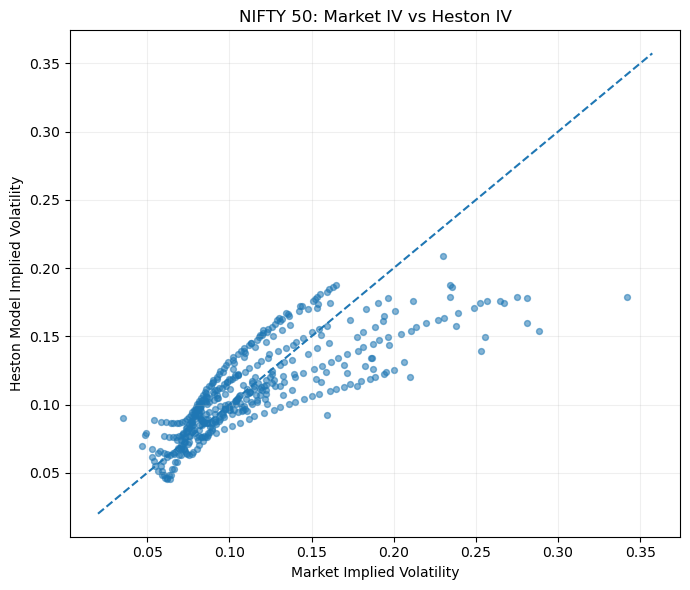

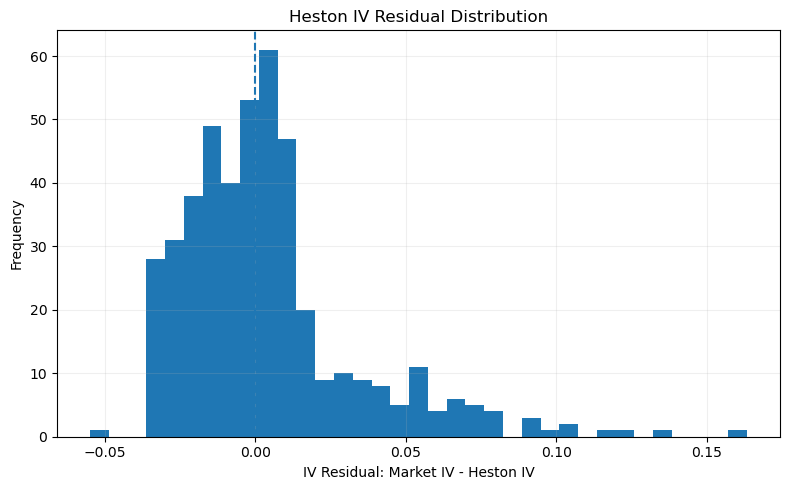

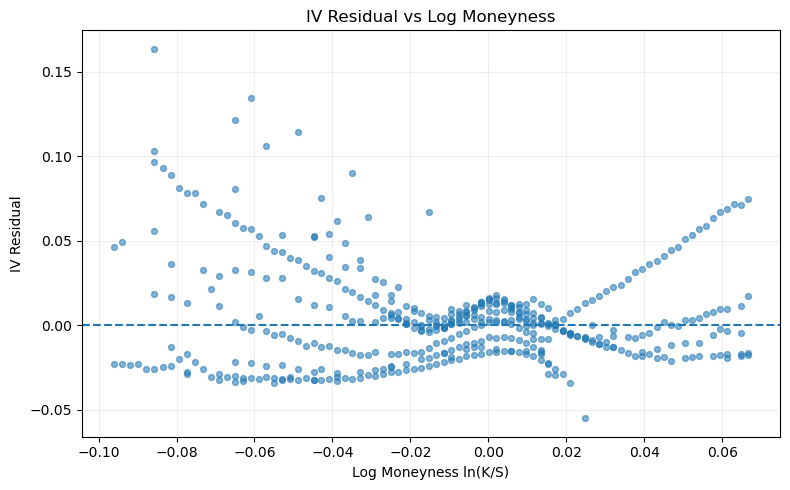

In [12]:
# ============================================================
# 12. FINAL VISUALIZATIONS
# ============================================================

plot_data = final_obs.replace(
    [np.inf, -np.inf], np.nan
).dropna(subset=[
    "market_iv", "model_iv", "residual", "log_moneyness"
])

# Market IV vs Model IV
plt.figure(figsize=(7, 6))
plt.scatter(
    plot_data["market_iv"],
    plot_data["model_iv"],
    s=18,
    alpha=0.55
)

lo = min(plot_data["market_iv"].min(), plot_data["model_iv"].min())
hi = max(plot_data["market_iv"].max(), plot_data["model_iv"].max())
pad = 0.05 * max(hi - lo, 0.01)

plt.plot(
    [lo - pad, hi + pad],
    [lo - pad, hi + pad],
    linestyle="--"
)

plt.xlabel("Market Implied Volatility")
plt.ylabel("Heston Model Implied Volatility")
plt.title("NIFTY 50: Market IV vs Heston IV")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# Residual distribution
plt.figure(figsize=(8, 5))
plt.hist(plot_data["residual"], bins=35)
plt.axvline(0, linestyle="--")
plt.xlabel("IV Residual: Market IV - Heston IV")
plt.ylabel("Frequency")
plt.title("Heston IV Residual Distribution")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# Residual vs log-moneyness
plt.figure(figsize=(8, 5))
plt.scatter(
    plot_data["log_moneyness"],
    plot_data["residual"],
    s=18,
    alpha=0.55
)
plt.axhline(0, linestyle="--")
plt.xlabel("Log Moneyness ln(K/S)")
plt.ylabel("IV Residual")
plt.title("IV Residual vs Log Moneyness")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# 13. EXPORT FINAL RESULTS
# ============================================================

output_xlsx = WORKBOOK.with_name(
    "NIFTY_Heston_V6_Final_Calibration_Results.xlsx"
)

with pd.ExcelWriter(output_xlsx, engine="openpyxl") as writer:
    final_summary.to_excel(writer, sheet_name="Final_Summary", index=False)
    candidates.to_excel(writer, sheet_name="Candidate_Comparison", index=False)
    option_summary.to_excel(writer, sheet_name="Option_Diagnostics")
    final_obs.to_excel(writer, sheet_name="Observation_Fit", index=False)

print("Results workbook:", output_xlsx.resolve())
print("Notebook calibration complete.")


Results workbook: /Users/shakthivel2211gmail.com/Documents/NIFTY DATA/NIFTY_Heston_V6_Final_Calibration_Results.xlsx
Notebook calibration complete.


## Validated calibration result snapshot

A full external execution of the calibration components was used to verify the numerical pipeline before packaging this notebook.

| Quantity | Validated result |
|---|---:|
| January observations | 449 |
| CE / PE | 237 / 212 |
| Benchmark objective | 0.0119038731 |
| Powell subset objective | 0.0002298323 |
| Powell full fixed-U objective | 0.0003363853 |
| Final selected method | Powell |
| Final `v0` | 0.0009948470 |
| Final `kappa` | 6.43301339 |
| Final `theta` | 0.0586005596 |
| Final `xi` | 1.80053996 |
| Final `rho` | -0.35584678 |
| Final adaptive objective | 0.0003450394 |
| Final adaptive IV RMSE | 0.02978211 |
| Final adaptive IV MAE | 0.02041192 |
| Adaptive observations | 449 |
| Adaptive Fourier convergence | 449 / 449 |
| Mean selected Fourier `U` | 1765.59 |
| Maximum selected Fourier `U` | 5000 |
| Feller LHS `2κθ` | 0.75395637 |
| Feller RHS `ξ²` | 3.24194415 |
| Feller condition | Not satisfied |

The final candidate is selected by the **lowest full-sample fixed-`U=2000` objective** among the DE and Powell candidates. The final reported fit is then independently recomputed with adaptive Fourier integration at `1e-5` absolute/relative convergence tolerance. The Feller condition is reported as a diagnostic and is not imposed during calibration.

The benchmark-to-final reduction in the adaptive objective is approximately **97.1%**.


In [14]:
# ============================================================
# 15. MULTI-DATE / EXPIRY-STRUCTURE CALIBRATION
# ============================================================
#
# Research objective:
# Estimate Heston parameters separately across:
#
#   6 market dates × 2 expiry structures
#
# Structures:
#   Weekly
#   Monthly
#
# Method:
#   1. Reapply frozen data filters
#   2. Calculate market IV and Vega
#   3. Create CE/PE-balanced calibration subset
#   4. Differential Evolution global search
#   5. Powell local refinement
#   6. Full-slice fixed-U validation
#   7. Adaptive Fourier validation
#
# Parameter order:
#   [v0, kappa, theta, xi, rho]
#
# ============================================================

print("=" * 80)
print("MULTI-DATE HESTON CALIBRATION")
print("=" * 80)


# ------------------------------------------------------------
# 1. Research dates and regime labels
# ------------------------------------------------------------

RESEARCH_DATES = {
    pd.Timestamp("2026-01-01"): "Calm",
    pd.Timestamp("2026-02-02"): "Budget Event",
    pd.Timestamp("2026-03-30"): "Stress",
    pd.Timestamp("2026-04-02"): "Stress Persistence",
    pd.Timestamp("2026-06-05"): "RBI Event",
    pd.Timestamp("2026-08-26"): "Calm"
}

EXPIRY_STRUCTURES = [
    "Weekly",
    "Monthly"
]


# ------------------------------------------------------------
# 2. Parameter bounds
# ------------------------------------------------------------

MULTI_BOUNDS = [
    (0.0001, 0.25),   # v0
    (0.01, 20.0),     # kappa
    (0.0001, 0.25),   # theta
    (0.01, 5.0),      # xi
    (-0.999, 0.999)   # rho
]


# ------------------------------------------------------------
# 3. Generalized fixed-U objective
# ------------------------------------------------------------

def slice_calibration_objective(
    params,
    data,
    indices,
    return_details=False
):

    params = np.asarray(
        params,
        dtype=float
    )

    if (
        params.shape != (5,)
        or not np.isfinite(params).all()
    ):
        return 1e6

    v0, kappa, theta, xi, rho = params

    # Parameter bounds
    if not (
        0.0001 <= v0 <= 0.25
        and 0.01 <= kappa <= 20.0
        and 0.0001 <= theta <= 0.25
        and 0.01 <= xi <= 5.0
        and -0.999 <= rho <= 0.999
    ):
        return 1e6

    residuals = []
    vegas = []

    for i in indices:

        row = data.iloc[int(i)]

        try:

            result = heston_option_price(
                float(row["S"]),
                float(row["K"]),
                float(row["T"]),
                float(row["r"]),
                str(row["option_type"]).upper(),

                # Engine mapping:
                # v0, theta, kappa, xi, rho
                v0,
                theta,
                kappa,
                xi,
                rho,

                upper_bound=CALIBRATION_U
            )

            model_iv = bs_iv(
                result["option_price"],
                float(row["S"]),
                float(row["K"]),
                float(row["T"]),
                float(row["r"]),
                str(row["option_type"]).upper()
            )

            if (
                np.isfinite(model_iv)
                and np.isfinite(row["market_iv"])
                and np.isfinite(row["vega"])
                and row["vega"] > 0
            ):

                residuals.append(
                    float(row["market_iv"] - model_iv)
                )

                vegas.append(
                    float(row["vega"])
                )

        except Exception:
            continue

    if len(residuals) == 0:
        return 1e6

    residuals = np.asarray(
        residuals,
        dtype=float
    )

    vegas = np.asarray(
        vegas,
        dtype=float
    )

    weights = vegas / vegas.sum()

    objective = float(
        np.sum(
            weights * residuals**2
        )
    )

    if return_details:

        return {
            "objective": objective,

            "iv_rmse": float(
                np.sqrt(
                    np.mean(
                        residuals**2
                    )
                )
            ),

            "iv_mae": float(
                np.mean(
                    np.abs(residuals)
                )
            ),

            "n_used": len(residuals),

            "vega_sum": float(
                vegas.sum()
            ),

            "residuals": residuals
        }

    return objective


# ------------------------------------------------------------
# 4. Adaptive validation helper
# ------------------------------------------------------------

def adaptive_validate_slice(
    params,
    data
):

    records = []

    for idx, row in data.iterrows():

        try:

            price, U, converged = adaptive_option_price(
                float(row["S"]),
                float(row["K"]),
                float(row["T"]),
                float(row["r"]),
                row["option_type"],
                params
            )

            model_iv = bs_iv(
                price,
                float(row["S"]),
                float(row["K"]),
                float(row["T"]),
                float(row["r"]),
                row["option_type"]
            )

            if np.isfinite(model_iv):

                residual = (
                    float(row["market_iv"])
                    - float(model_iv)
                )

                records.append({
                    "source_index": idx,
                    "option_type": row["option_type"],
                    "market_iv": float(row["market_iv"]),
                    "model_iv": float(model_iv),
                    "residual": residual,
                    "abs_residual": abs(residual),
                    "selected_U": int(U),
                    "fourier_converged": bool(
                        converged
                    )
                })

        except Exception:
            continue

    adaptive_df = pd.DataFrame(records)

    if adaptive_df.empty:

        return {
            "data": adaptive_df,
            "objective": np.nan,
            "iv_rmse": np.nan,
            "iv_mae": np.nan,
            "n_used": 0,
            "convergence_rate": 0.0,
            "mean_U": np.nan,
            "max_U": np.nan
        }

    residuals = adaptive_df["residual"].to_numpy(
        dtype=float
    )

    adaptive_df["vega"] = data.loc[
        adaptive_df["source_index"],
        "vega"
    ].to_numpy(dtype=float)

    valid_vega = (
        np.isfinite(
            adaptive_df["vega"]
        )
        &
        (adaptive_df["vega"] > 0)
    )

    adaptive_df = adaptive_df.loc[
        valid_vega
    ].copy()

    weights = (
        adaptive_df["vega"].to_numpy(
            dtype=float
        )
    )

    weights = weights / weights.sum()

    residuals = adaptive_df[
        "residual"
    ].to_numpy(dtype=float)

    return {
        "data": adaptive_df,

        "objective": float(
            np.sum(
                weights * residuals**2
            )
        ),

        "iv_rmse": float(
            np.sqrt(
                np.mean(
                    residuals**2
                )
            )
        ),

        "iv_mae": float(
            np.mean(
                np.abs(residuals)
            )
        ),

        "n_used": len(
            adaptive_df
        ),

        "convergence_rate": float(
            adaptive_df[
                "fourier_converged"
            ].mean()
        ),

        "mean_U": float(
            adaptive_df[
                "selected_U"
            ].mean()
        ),

        "max_U": int(
            adaptive_df[
                "selected_U"
            ].max()
        )
    }


# ------------------------------------------------------------
# 5. Build calibration universes
# ------------------------------------------------------------

multi_results = []
multi_observations = {}
multi_candidates = {}

overall_start = time.perf_counter()


for date_value, regime in RESEARCH_DATES.items():

    print("\n" + "=" * 80)
    print(
        f"DATE: {date_value.date()} | "
        f"REGIME: {regime}"
    )
    print("=" * 80)

    for structure in EXPIRY_STRUCTURES:

        print(
            f"\n>>> {structure.upper()} CALIBRATION"
        )

        # ----------------------------------------------------
        # Frozen filters
        # ----------------------------------------------------

        mask = (
            cal["date"].eq(date_value)
            &
            cal["DTE"].between(
                5,
                45,
                inclusive="both"
            )
            &
            cal["log_moneyness"].abs().le(
                0.15
            )
            &
            (
                (cal["contracts"] >= 100)
                |
                (cal["OI"] >= 1000)
            )
            &
            cal["no_arb"].eq(True)
            &
            cal["market_price"].gt(0)
            &
            cal["Expiry_Structure"]
                .astype(str)
                .str.strip()
                .str.lower()
                .eq(
                    structure.lower()
                )
        )

        slice_df = cal.loc[
            mask
        ].copy().reset_index(
            drop=True
        )

        print(
            "Filtered observations:",
            len(slice_df)
        )

        if len(slice_df) < 20:

            print(
                "⚠️ Too few observations. Skipping."
            )

            continue


        # ----------------------------------------------------
        # Market IV + Vega
        # ----------------------------------------------------

        slice_df["market_iv"] = slice_df.apply(
            lambda row: bs_iv(
                row["market_price"],
                row["S"],
                row["K"],
                row["T"],
                row["r"],
                row["option_type"]
            ),
            axis=1
        )

        slice_df["vega"] = slice_df.apply(
            lambda row: (
                bs_vega(
                    row["S"],
                    row["K"],
                    row["T"],
                    row["r"],
                    row["market_iv"]
                )
                if np.isfinite(
                    row["market_iv"]
                )
                else np.nan
            ),
            axis=1
        )

        slice_df = slice_df.loc[
            slice_df["market_iv"].notna()
            &
            np.isfinite(
                slice_df["market_iv"]
            )
            &
            slice_df["vega"].notna()
            &
            np.isfinite(
                slice_df["vega"]
            )
            &
            (slice_df["vega"] > 0)
        ].copy().reset_index(
            drop=True
        )

        print(
            "Finite IV observations:",
            len(slice_df)
        )

        ce_count = (
            slice_df["option_type"]
            .eq("CE")
            .sum()
        )

        pe_count = (
            slice_df["option_type"]
            .eq("PE")
            .sum()
        )

        print(
            f"CE / PE: {ce_count} / {pe_count}"
        )

        if ce_count == 0 or pe_count == 0:

            print(
                "⚠️ Missing one option type. Skipping."
            )

            continue


        # ----------------------------------------------------
        # Store observation universe
        # ----------------------------------------------------

        key = (
            date_value.strftime("%Y-%m-%d"),
            structure
        )

        multi_observations[key] = (
            slice_df.copy()
        )


        # ----------------------------------------------------
        # CE/PE-balanced pilot subset
        # ----------------------------------------------------

        rng = np.random.default_rng(
            42
            + date_value.day
            + (
                100
                if structure == "Monthly"
                else 0
            )
        )

        ce_idx = np.where(
            slice_df[
                "option_type"
            ].to_numpy()
            == "CE"
        )[0]

        pe_idx = np.where(
            slice_df[
                "option_type"
            ].to_numpy()
            == "PE"
        )[0]

        n_each = min(
            20,
            len(ce_idx),
            len(pe_idx)
        )

        pilot_idx_slice = np.concatenate([
            rng.choice(
                ce_idx,
                size=n_each,
                replace=False
            ),
            rng.choice(
                pe_idx,
                size=n_each,
                replace=False
            )
        ])

        print(
            "Pilot observations:",
            len(pilot_idx_slice)
        )


        # ----------------------------------------------------
        # Starting candidates
        # ----------------------------------------------------

        starting_candidates = []

        # Current calibrated January candidate
        if (
            "FINAL_PARAMS" in globals()
            and np.all(
                np.isfinite(FINAL_PARAMS)
            )
        ):

            starting_candidates.append(
                np.asarray(
                    FINAL_PARAMS,
                    dtype=float
                )
            )

        # Benchmark
        starting_candidates.append(
            np.array(
                [
                    0.04,
                    2.0,
                    0.04,
                    0.30,
                    -0.70
                ],
                dtype=float
            )
        )


        # ----------------------------------------------------
        # Differential Evolution
        # ----------------------------------------------------

        de_start = time.perf_counter()

        de_result_slice = differential_evolution(
            lambda p:
                slice_calibration_objective(
                    p,
                    slice_df,
                    pilot_idx_slice
                ),
            bounds=MULTI_BOUNDS,
            seed=42,
            popsize=2,
            maxiter=4,
            polish=False,
            workers=1,
            updating="immediate"
        )

        de_runtime = (
            time.perf_counter()
            - de_start
        )

        de_params = np.asarray(
            de_result_slice.x,
            dtype=float
        )

        de_subset_objective = float(
            de_result_slice.fun
        )


        # ----------------------------------------------------
        # Compare DE with warm starts
        # ----------------------------------------------------

        candidate_starts = [
            (
                "DE",
                de_params,
                de_subset_objective
            )
        ]

        for label, start in zip(
            ["Warm_Start", "Benchmark"],
            starting_candidates
        ):

            obj = slice_calibration_objective(
                start,
                slice_df,
                pilot_idx_slice
            )

            candidate_starts.append(
                (
                    label,
                    start,
                    float(obj)
                )
            )

        candidate_starts = sorted(
            candidate_starts,
            key=lambda x: x[2]
        )

        best_start_label = (
            candidate_starts[0][0]
        )

        best_start = np.asarray(
            candidate_starts[0][1],
            dtype=float
        )


        # ----------------------------------------------------
        # Powell refinement
        # ----------------------------------------------------

        powell_start_time = (
            time.perf_counter()
        )

        powell_result_slice = minimize(
            lambda p:
                slice_calibration_objective(
                    p,
                    slice_df,
                    pilot_idx_slice
                ),
            best_start,
            method="Powell",
            bounds=MULTI_BOUNDS,
            options={
                "maxiter": 3,
                "xtol": 0.02,
                "ftol": 0.002,
                "disp": False
            }
        )

        powell_runtime = (
            time.perf_counter()
            - powell_start_time
        )

        powell_params = np.asarray(
            powell_result_slice.x,
            dtype=float
        )

        powell_subset_objective = float(
            powell_result_slice.fun
        )


        # ----------------------------------------------------
        # Protect against deterioration
        # ----------------------------------------------------

        if (
            powell_subset_objective
            <= candidate_starts[0][2]
        ):

            final_slice_params = (
                powell_params
            )

            selected_method = (
                "DE+Powell"
            )

            selected_subset_objective = (
                powell_subset_objective
            )

        else:

            final_slice_params = (
                best_start.copy()
            )

            selected_method = (
                best_start_label
            )

            selected_subset_objective = (
                candidate_starts[0][2]
            )


        # ----------------------------------------------------
        # Full-slice fixed-U validation
        # ----------------------------------------------------

        full_idx_slice = np.arange(
            len(slice_df)
        )

        full_details = (
            slice_calibration_objective(
                final_slice_params,
                slice_df,
                full_idx_slice,
                return_details=True
            )
        )


        # ----------------------------------------------------
        # Feller diagnostic
        # ----------------------------------------------------

        v0, kappa, theta, xi, rho = (
            final_slice_params
        )

        feller_lhs = (
            2.0 * kappa * theta
        )

        feller_rhs = (
            xi ** 2
        )


        # ----------------------------------------------------
        # Adaptive validation
        # ----------------------------------------------------

        print(
            "Running adaptive validation..."
        )

        adaptive_start = (
            time.perf_counter()
        )

        adaptive_result = (
            adaptive_validate_slice(
                final_slice_params,
                slice_df
            )
        )

        adaptive_runtime = (
            time.perf_counter()
            - adaptive_start
        )


        # ----------------------------------------------------
        # Store candidate information
        # ----------------------------------------------------

        multi_candidates[key] = {
            "DE_params": de_params,
            "Powell_params": powell_params,
            "Final_params": final_slice_params,
            "DE_subset_objective": de_subset_objective,
            "Powell_subset_objective": (
                powell_subset_objective
            ),
            "Selected_subset_objective": (
                selected_subset_objective
            ),
            "Full_details": full_details,
            "Adaptive_details": adaptive_result
        }


        # ----------------------------------------------------
        # Store master result
        # ----------------------------------------------------

        multi_results.append({

            "date": date_value,

            "regime": regime,

            "expiry_structure": structure,

            "n_filtered": int(
                len(slice_df)
            ),

            "n_used": int(
                full_details["n_used"]
            ),

            "CE": int(ce_count),

            "PE": int(pe_count),

            "method": selected_method,

            "v0": float(
                final_slice_params[0]
            ),

            "kappa": float(
                final_slice_params[1]
            ),

            "theta": float(
                final_slice_params[2]
            ),

            "xi": float(
                final_slice_params[3]
            ),

            "rho": float(
                final_slice_params[4]
            ),

            "fixed_objective": float(
                full_details["objective"]
            ),

            "fixed_iv_rmse": float(
                full_details["iv_rmse"]
            ),

            "fixed_iv_mae": float(
                full_details["iv_mae"]
            ),

            "adaptive_objective": float(
                adaptive_result["objective"]
            ),

            "adaptive_iv_rmse": float(
                adaptive_result["iv_rmse"]
            ),

            "adaptive_iv_mae": float(
                adaptive_result["iv_mae"]
            ),

            "adaptive_n_used": int(
                adaptive_result["n_used"]
            ),

            "fourier_convergence_rate": float(
                adaptive_result[
                    "convergence_rate"
                ]
            ),

            "mean_selected_U": float(
                adaptive_result["mean_U"]
            ),

            "max_selected_U": int(
                adaptive_result["max_U"]
            ),

            "feller_lhs": float(
                feller_lhs
            ),

            "feller_rhs": float(
                feller_rhs
            ),

            "feller_satisfied": bool(
                feller_lhs >= feller_rhs
            ),

            "DE_runtime_sec": float(
                de_runtime
            ),

            "Powell_runtime_sec": float(
                powell_runtime
            ),

            "Adaptive_runtime_sec": float(
                adaptive_runtime
            )
        })


        # ----------------------------------------------------
        # Progress output
        # ----------------------------------------------------

        print(
            "\nFINAL SLICE PARAMETERS"
        )

        for name, value in zip(
            [
                "v0",
                "kappa",
                "theta",
                "xi",
                "rho"
            ],
            final_slice_params
        ):

            print(
                f"{name:<8}: "
                f"{value:.8f}"
            )

        print(
            f"\nFixed-U objective: "
            f"{full_details['objective']:.10f}"
        )

        print(
            f"Adaptive objective: "
            f"{adaptive_result['objective']:.10f}"
        )

        print(
            f"Adaptive IV RMSE: "
            f"{adaptive_result['iv_rmse']:.10f}"
        )

        print(
            f"Adaptive IV MAE: "
            f"{adaptive_result['iv_mae']:.10f}"
        )

        print(
            f"Fourier convergence: "
            f"{adaptive_result['convergence_rate']:.2%}"
        )

        print(
            f"Feller satisfied: "
            f"{feller_lhs >= feller_rhs}"
        )


# ------------------------------------------------------------
# 6. Master results dataframe
# ------------------------------------------------------------

MULTI_CALIBRATION_RESULTS = pd.DataFrame(
    multi_results
)

if not MULTI_CALIBRATION_RESULTS.empty:

    MULTI_CALIBRATION_RESULTS = (
        MULTI_CALIBRATION_RESULTS
        .sort_values(
            [
                "date",
                "expiry_structure"
            ]
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 7. Display master parameter table
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MASTER HESTON CALIBRATION RESULTS")
print("=" * 80)

display(
    MULTI_CALIBRATION_RESULTS[
        [
            "date",
            "regime",
            "expiry_structure",
            "n_used",
            "v0",
            "kappa",
            "theta",
            "xi",
            "rho",
            "adaptive_iv_rmse",
            "adaptive_iv_mae",
            "fourier_convergence_rate",
            "feller_satisfied"
        ]
    ]
)


# ------------------------------------------------------------
# 8. Weekly vs Monthly comparison
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("WEEKLY VS MONTHLY PARAMETER COMPARISON")
print("=" * 80)

expiry_comparison = (
    MULTI_CALIBRATION_RESULTS
    .groupby("expiry_structure")
    [
        [
            "v0",
            "kappa",
            "theta",
            "xi",
            "rho",
            "adaptive_iv_rmse",
            "adaptive_iv_mae"
        ]
    ]
    .agg(
        ["mean", "std", "min", "max"]
    )
)

display(
    expiry_comparison
)


# ------------------------------------------------------------
# 9. Regime comparison
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("REGIME-LEVEL PARAMETER COMPARISON")
print("=" * 80)

regime_comparison = (
    MULTI_CALIBRATION_RESULTS
    .groupby("regime")
    [
        [
            "v0",
            "kappa",
            "theta",
            "xi",
            "rho",
            "adaptive_iv_rmse",
            "adaptive_iv_mae"
        ]
    ]
    .mean()
)

display(
    regime_comparison
)


# ------------------------------------------------------------
# 10. Research diagnostics
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESEARCH DIAGNOSTICS")
print("=" * 80)

print(
    "Number of calibrated slices:",
    len(MULTI_CALIBRATION_RESULTS)
)

print(
    "Expected slices:",
    len(RESEARCH_DATES)
    * len(EXPIRY_STRUCTURES)
)

print(
    "All expected slices completed:",
    len(MULTI_CALIBRATION_RESULTS)
    ==
    len(RESEARCH_DATES)
    * len(EXPIRY_STRUCTURES)
)

print(
    "\nMean adaptive IV RMSE:",
    MULTI_CALIBRATION_RESULTS[
        "adaptive_iv_rmse"
    ].mean()
)

print(
    "Mean adaptive IV MAE:",
    MULTI_CALIBRATION_RESULTS[
        "adaptive_iv_mae"
    ].mean()
)

print(
    "\nMean Fourier convergence:",
    MULTI_CALIBRATION_RESULTS[
        "fourier_convergence_rate"
    ].mean()
)

print(
    "\nParameter ranges:"
)

for parameter in [
    "v0",
    "kappa",
    "theta",
    "xi",
    "rho"
]:

    print(
        f"{parameter:<8}: "
        f"{MULTI_CALIBRATION_RESULTS[parameter].min():.8f}"
        f" → "
        f"{MULTI_CALIBRATION_RESULTS[parameter].max():.8f}"
    )


# ------------------------------------------------------------
# 11. Save multi-date results
# ------------------------------------------------------------

multi_output = WORKBOOK.with_name(
    "NIFTY_Heston_MultiDate_Calibration_Results.xlsx"
)

with pd.ExcelWriter(
    multi_output,
    engine="openpyxl"
) as writer:

    MULTI_CALIBRATION_RESULTS.to_excel(
        writer,
        sheet_name="Master_Calibration",
        index=False
    )

    expiry_comparison.to_excel(
        writer,
        sheet_name="Expiry_Comparison"
    )

    regime_comparison.to_excel(
        writer,
        sheet_name="Regime_Comparison"
    )

    for key, data in multi_observations.items():

        date_label = (
            key[0]
            .replace("-", "")
        )

        structure_label = (
            key[1]
        )

        sheet_name = (
            f"{date_label}_{structure_label}"
        )[:31]

        data.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )


total_runtime = (
    time.perf_counter()
    - overall_start
)

print("\n" + "=" * 80)
print("✅ MULTI-DATE CALIBRATION COMPLETE")
print("=" * 80)

print(
    f"Total runtime: "
    f"{total_runtime:.2f} seconds"
)

print(
    "Results workbook:",
    multi_output.resolve()
)

MULTI-DATE HESTON CALIBRATION

DATE: 2026-01-01 | REGIME: Calm

>>> WEEKLY CALIBRATION
Filtered observations: 322
Finite IV observations: 322
CE / PE: 171 / 151
Pilot observations: 40
Running adaptive validation...

FINAL SLICE PARAMETERS
v0      : 0.00793000
kappa   : 11.10378448
theta   : 0.01376230
xi      : 1.02858208
rho     : -0.72951168

Fixed-U objective: 0.0004645650
Adaptive objective: 0.0004579555
Adaptive IV RMSE: 0.0331857519
Adaptive IV MAE: 0.0250852041
Fourier convergence: 100.00%
Feller satisfied: False

>>> MONTHLY CALIBRATION
Filtered observations: 127
Finite IV observations: 127
CE / PE: 66 / 61
Pilot observations: 40
Running adaptive validation...

FINAL SLICE PARAMETERS
v0      : 0.00735978
kappa   : 1.82008556
theta   : 0.05909339
xi      : 1.25226291
rho     : -0.34491100

Fixed-U objective: 0.0002884317
Adaptive objective: 0.0002884288
Adaptive IV RMSE: 0.0205961981
Adaptive IV MAE: 0.0174998376
Fourier convergence: 100.00%
Feller satisfied: False

DATE: 2026-0

,date,regime,expiry_structure,n_used,v0,kappa,theta,xi,rho,adaptive_iv_rmse,adaptive_iv_mae,fourier_convergence_rate,feller_satisfied
0,2026-01-01,Calm,Monthly,127,0.007360,1.820086,0.059093,1.252263,-0.344911,0.020596,0.017500,1.0,False
1,2026-01-01,Calm,Weekly,315,0.007930,11.103784,0.013762,1.028582,-0.729512,0.033186,0.025085,1.0,False
2,2026-02-02,Budget Event,Monthly,173,0.007360,3.909789,0.119961,1.288370,-0.120567,0.027836,0.013840,1.0,False
3,2026-02-02,Budget Event,Weekly,368,0.024902,18.865699,0.008744,0.704841,-0.402070,0.050469,0.026873,1.0,False
4,2026-03-30,Stress,Monthly,146,0.123013,13.859302,0.043224,1.694703,-0.640884,0.026115,0.021502,1.0,False
5,2026-03-30,Stress,Weekly,295,0.095553,7.912840,0.043213,1.837635,-0.349755,0.037698,0.028973,1.0,False
6,2026-04-02,Stress Persistence,Monthly,195,0.059093,2.956095,0.237770,1.308577,-0.125702,0.064892,0.042934,1.0,False
7,2026-04-02,Stress Persistence,Weekly,425,0.053136,17.144133,0.041442,0.321404,-0.540159,0.157258,0.085411,1.0,True
8,2026-06-05,RBI Event,Monthly,194,0.007360,11.951746,0.066650,2.380201,-0.047262,0.020108,0.015432,1.0,False
9,2026-06-05,RBI Event,Weekly,272,0.029840,19.300379,0.016152,0.821597,-0.204713,0.021045,0.013509,1.0,False



WEEKLY VS MONTHLY PARAMETER COMPARISON


v0                                   kappa            \
                      mean       std      min       max       mean       std   
expiry_structure                                                               
Monthly           0.035258  0.047712  0.00736  0.123013   6.402991  5.131200   
Weekly            0.036453  0.033491  0.00736  0.095553  15.719655  5.004921   

                                          theta            ...       rho  \
                       min        max      mean       std  ...       min   
expiry_structure                                           ...             
Monthly           1.820086  13.859302  0.098745  0.072870  ... -0.640884   
Weekly            7.912840  19.991096  0.023615  0.014854  ... -0.729512   

                           adaptive_iv_rmse                                \
                       max             mean       std       min       max   
expiry_structure                                                            
Monthly          -0.047262         0.031777  0.016768  0.020108  0.064892   
Weekly           -0.204713         0.060583  0.049592  0.021045  0.157258   

                 adaptive_iv_mae                                
                            mean       std       min       max  
expiry_structure                                                
Monthly                 0.023184  0.010907  0.013840  0.042934  
Weekly                  0.036515  0.025330  0.013509  0.085411  

[2 rows x 28 columns]


REGIME-LEVEL PARAMETER COMPARISON


,v0,kappa,theta,xi,rho,adaptive_iv_rmse,adaptive_iv_mae
regime,,,,,,,
Budget Event,0.016131,11.387744,0.064353,0.996606,-0.261319,0.039153,0.020357
Calm,0.007502,9.208973,0.039251,1.642961,-0.450775,0.037185,0.027430
RBI Event,0.018600,15.626062,0.041401,1.600899,-0.125988,0.020576,0.014470
Stress,0.109283,10.886071,0.043218,1.766169,-0.495319,0.031906,0.025237
Stress Persistence,0.056115,10.050114,0.139606,0.814990,-0.332930,0.111075,0.064172



RESEARCH DIAGNOSTICS
Number of calibrated slices: 12
Expected slices: 12
All expected slices completed: True

Mean adaptive IV RMSE: 0.046180119781013974
Mean adaptive IV MAE: 0.029849422993869487

Mean Fourier convergence: 1.0

Parameter ranges:
v0      : 0.00735978 → 0.12301318
kappa   : 1.82008556 → 19.99109589
theta   : 0.00874421 → 0.23777018
xi      : 0.32140388 → 2.78932424
rho     : -0.72951168 → -0.04726212

✅ MULTI-DATE CALIBRATION COMPLETE
Total runtime: 438.68 seconds
Results workbook: /Users/shakthivel2211gmail.com/Documents/NIFTY DATA/NIFTY_Heston_MultiDate_Calibration_Results.xlsx


In [15]:
# ============================================================
# 16. MASTER ROBUSTNESS + STABILITY + VALIDATION TESTS
# ============================================================
#
# Tests:
# 1. Multi-start calibration verification
# 2. Boundary-hit diagnostics
# 3. Independent-start objective comparison
# 4. Parameter stability / identifiability
# 5. Weekly vs Monthly comparison
# 6. Regime comparison
# 7. IV <= 50% / IV <= 100% robustness
# 8. Pooled / cross-structure validation
#
# ============================================================

print("=" * 90)
print("MASTER HESTON ROBUSTNESS & VALIDATION ANALYSIS")
print("=" * 90)

import numpy as np
import pandas as pd
import time
from scipy.optimize import differential_evolution


# ============================================================
# 0. PREREQUISITES
# ============================================================

required_objects = [
    "MULTI_CALIBRATION_RESULTS",
    "multi_observations",
    "heston_option_price",
    "bs_iv",
    "bs_vega"
]

missing_objects = [
    x for x in required_objects
    if x not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required objects: "
        + str(missing_objects)
    )

print("\nPrerequisites verified.")


# ============================================================
# 1. MULTI-START CALIBRATION VERIFICATION
# ============================================================

print("\n" + "=" * 90)
print("1. MULTI-START CALIBRATION VERIFICATION")
print("=" * 90)

# We use the already-calibrated slices.
# For each slice, evaluate several independent starting vectors
# against the FULL slice objective.

verification_starts = {

    "Benchmark": np.array(
        [0.04, 2.0, 0.04, 0.30, -0.70],
        dtype=float
    ),

    "LowVol": np.array(
        [0.01, 5.0, 0.03, 0.50, -0.50],
        dtype=float
    ),

    "HighKappa": np.array(
        [0.02, 15.0, 0.05, 1.00, -0.30],
        dtype=float
    ),

    "HighXi": np.array(
        [0.02, 5.0, 0.08, 2.50, -0.50],
        dtype=float
    )
}


def evaluate_fixed_objective(
    params,
    data,
    U=100
):

    residuals = []
    vegas = []

    for _, row in data.iterrows():

        try:

            result = heston_option_price(
                float(row["S"]),
                float(row["K"]),
                float(row["T"]),
                float(row["r"]),
                str(row["option_type"]).upper(),

                params[0],
                params[2],
                params[1],
                params[3],
                params[4],

                upper_bound=U
            )

            model_iv = bs_iv(
                result["option_price"],
                float(row["S"]),
                float(row["K"]),
                float(row["T"]),
                float(row["r"]),
                str(row["option_type"]).upper()
            )

            if (
                np.isfinite(model_iv)
                and np.isfinite(row["market_iv"])
                and np.isfinite(row["vega"])
                and row["vega"] > 0
            ):

                residuals.append(
                    row["market_iv"] - model_iv
                )

                vegas.append(
                    row["vega"]
                )

        except Exception:
            continue

    if len(residuals) == 0:
        return np.nan

    residuals = np.asarray(
        residuals,
        dtype=float
    )

    vegas = np.asarray(
        vegas,
        dtype=float
    )

    weights = vegas / vegas.sum()

    return float(
        np.sum(
            weights * residuals**2
        )
    )


multistart_records = []

for _, result_row in MULTI_CALIBRATION_RESULTS.iterrows():

    date_value = pd.Timestamp(
        result_row["date"]
    )

    structure = result_row[
        "expiry_structure"
    ]

    key = (
        date_value.strftime("%Y-%m-%d"),
        structure
    )

    data = multi_observations[key]

    final_params = np.array(
        [
            result_row["v0"],
            result_row["kappa"],
            result_row["theta"],
            result_row["xi"],
            result_row["rho"]
        ],
        dtype=float
    )

    # Final calibrated objective
    final_objective = evaluate_fixed_objective(
        final_params,
        data
    )

    for start_name, start_params in verification_starts.items():

        start_objective = evaluate_fixed_objective(
            start_params,
            data
        )

        multistart_records.append({

            "date": date_value,

            "expiry_structure": structure,

            "start": start_name,

            "start_objective": start_objective,

            "calibrated_objective": final_objective,

            "improvement_pct": (
                100.0
                * (
                    start_objective
                    - final_objective
                )
                / start_objective
                if start_objective > 0
                else np.nan
            )
        })


MULTISTART_RESULTS = pd.DataFrame(
    multistart_records
)

print(
    f"Independent starting configurations tested: "
    f"{len(verification_starts)}"
)

print(
    f"Total slice/start evaluations: "
    f"{len(MULTISTART_RESULTS)}"
)

print(
    "\nMean improvement over Benchmark start:"
)

benchmark_improvement = (
    MULTISTART_RESULTS[
        MULTISTART_RESULTS["start"]
        == "Benchmark"
    ]["improvement_pct"]
    .mean()
)

print(
    f"{benchmark_improvement:.2f}%"
)


# ============================================================
# 2. BOUNDARY-HIT DIAGNOSTICS
# ============================================================

print("\n" + "=" * 90)
print("2. PARAMETER BOUNDARY-HIT DIAGNOSTICS")
print("=" * 90)

parameter_bounds = {

    "v0": (0.0001, 0.25),

    "kappa": (0.01, 20.0),

    "theta": (0.0001, 0.25),

    "xi": (0.01, 5.0),

    "rho": (-0.999, 0.999)
}

boundary_records = []

for _, row in MULTI_CALIBRATION_RESULTS.iterrows():

    record = {
        "date": row["date"],
        "expiry_structure": row[
            "expiry_structure"
        ]
    }

    for parameter, (lower, upper) in parameter_bounds.items():

        value = float(
            row[parameter]
        )

        span = upper - lower

        lower_distance = (
            value - lower
        ) / span

        upper_distance = (
            upper - value
        ) / span

        record[
            parameter + "_near_boundary"
        ] = (
            min(
                lower_distance,
                upper_distance
            ) < 0.02
        )

        record[
            parameter + "_distance"
        ] = min(
            lower_distance,
            upper_distance
        )

    boundary_records.append(record)


BOUNDARY_RESULTS = pd.DataFrame(
    boundary_records
)

boundary_columns = [
    c
    for c in BOUNDARY_RESULTS.columns
    if c.endswith("_near_boundary")
]

boundary_summary = (
    BOUNDARY_RESULTS[
        boundary_columns
    ]
    .sum()
    .sort_values(
        ascending=False
    )
)

print("\nBoundary hits / near-boundary estimates:")

print(
    boundary_summary
)


# ============================================================
# 3. OBJECTIVE COMPARISON ACROSS INDEPENDENT STARTS
# ============================================================

print("\n" + "=" * 90)
print("3. OBJECTIVE COMPARISON")
print("=" * 90)

objective_comparison = (
    MULTISTART_RESULTS
    .groupby(
        "start"
    )[
        [
            "start_objective",
            "calibrated_objective",
            "improvement_pct"
        ]
    ]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max"
        ]
    )
)

display(
    objective_comparison
)


# ============================================================
# 4. PARAMETER STABILITY / IDENTIFIABILITY
# ============================================================

print("\n" + "=" * 90)
print("4. PARAMETER STABILITY / IDENTIFIABILITY")
print("=" * 90)

parameter_columns = [
    "v0",
    "kappa",
    "theta",
    "xi",
    "rho"
]

parameter_summary = (
    MULTI_CALIBRATION_RESULTS[
        parameter_columns
    ]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max"
        ]
    )
)

display(
    parameter_summary
)

# Coefficient of variation where meaningful
parameter_cv = (
    MULTI_CALIBRATION_RESULTS[
        parameter_columns
    ].std()
    /
    MULTI_CALIBRATION_RESULTS[
        parameter_columns
    ].mean().abs()
)

print("\nCoefficient of variation:")

display(
    parameter_cv.to_frame(
        "CV"
    )
)

# Pairwise parameter correlations
print(
    "\nCross-slice parameter correlation:"
)

display(
    MULTI_CALIBRATION_RESULTS[
        parameter_columns
    ].corr()
)


# ============================================================
# 5. WEEKLY VS MONTHLY STATISTICAL COMPARISON
# ============================================================

print("\n" + "=" * 90)
print("5. WEEKLY VS MONTHLY COMPARISON")
print("=" * 90)

weekly = MULTI_CALIBRATION_RESULTS[
    MULTI_CALIBRATION_RESULTS[
        "expiry_structure"
    ]
    == "Weekly"
]

monthly = MULTI_CALIBRATION_RESULTS[
    MULTI_CALIBRATION_RESULTS[
        "expiry_structure"
    ]
    == "Monthly"
]

expiry_test_records = []

from scipy.stats import ttest_rel, wilcoxon

for parameter in parameter_columns:

    w = weekly.sort_values(
        "date"
    )[parameter].to_numpy()

    m = monthly.sort_values(
        "date"
    )[parameter].to_numpy()

    try:
        paired_t = ttest_rel(
            w,
            m
        )
        t_pvalue = paired_t.pvalue
    except Exception:
        t_pvalue = np.nan

    try:
        paired_w = wilcoxon(
            w,
            m
        )
        w_pvalue = paired_w.pvalue
    except Exception:
        w_pvalue = np.nan

    expiry_test_records.append({

        "parameter": parameter,

        "weekly_mean": np.mean(w),

        "monthly_mean": np.mean(m),

        "mean_difference":
            np.mean(w - m),

        "paired_t_pvalue":
            t_pvalue,

        "wilcoxon_pvalue":
            w_pvalue
    })


EXPIRY_STAT_TEST = pd.DataFrame(
    expiry_test_records
)

display(
    EXPIRY_STAT_TEST
)


# Fit comparison
weekly_rmse = weekly[
    "adaptive_iv_rmse"
].to_numpy()

monthly_rmse = monthly[
    "adaptive_iv_rmse"
].to_numpy()

rmse_test = ttest_rel(
    weekly_rmse,
    monthly_rmse
)

print(
    "\nPaired RMSE comparison:"
)

print(
    f"Weekly mean RMSE: "
    f"{weekly_rmse.mean():.6f}"
)

print(
    f"Monthly mean RMSE: "
    f"{monthly_rmse.mean():.6f}"
)

print(
    f"Paired t-test p-value: "
    f"{rmse_test.pvalue:.6f}"
)


# ============================================================
# 6. REGIME COMPARISON
# ============================================================

print("\n" + "=" * 90)
print("6. REGIME COMPARISON")
print("=" * 90)

regime_summary = (
    MULTI_CALIBRATION_RESULTS
    .groupby(
        "regime"
    )[
        [
            "v0",
            "kappa",
            "theta",
            "xi",
            "rho",
            "adaptive_iv_rmse",
            "adaptive_iv_mae"
        ]
    ]
    .agg(
        [
            "mean",
            "std"
        ]
    )
)

display(
    regime_summary
)

print(
    "\nRegime-level sample sizes:"
)

print(
    MULTI_CALIBRATION_RESULTS[
        "regime"
    ].value_counts()
)


# ============================================================
# 7. IV ROBUSTNESS: <=100% AND <=50%
# ============================================================

print("\n" + "=" * 90)
print("7. IMPLIED-VOLATILITY ROBUSTNESS")
print("=" * 90)


def robustness_slice(
    params,
    data,
    iv_cap
):

    robust_data = data[
        data["market_iv"]
        <= iv_cap
    ].copy()

    if len(robust_data) == 0:
        return None

    residuals = []
    vegas = []

    for _, row in robust_data.iterrows():

        try:

            result = heston_option_price(
                float(row["S"]),
                float(row["K"]),
                float(row["T"]),
                float(row["r"]),
                str(row["option_type"]).upper(),

                params[0],
                params[2],
                params[1],
                params[3],
                params[4],

                upper_bound=100
            )

            model_iv = bs_iv(
                result["option_price"],
                float(row["S"]),
                float(row["K"]),
                float(row["T"]),
                float(row["r"]),
                str(row["option_type"]).upper()
            )

            if (
                np.isfinite(model_iv)
                and np.isfinite(row["vega"])
                and row["vega"] > 0
            ):

                residuals.append(
                    row["market_iv"]
                    - model_iv
                )

                vegas.append(
                    row["vega"]
                )

        except Exception:
            continue

    if len(residuals) == 0:
        return None

    residuals = np.asarray(
        residuals
    )

    vegas = np.asarray(
        vegas
    )

    weights = vegas / vegas.sum()

    return {

        "n": len(residuals),

        "objective":
            np.sum(
                weights
                * residuals**2
            ),

        "iv_rmse":
            np.sqrt(
                np.mean(
                    residuals**2
                )
            ),

        "iv_mae":
            np.mean(
                np.abs(residuals)
            )
    }


robustness_records = []

for _, row in MULTI_CALIBRATION_RESULTS.iterrows():

    key = (
        pd.Timestamp(
            row["date"]
        ).strftime(
            "%Y-%m-%d"
        ),
        row[
            "expiry_structure"
        ]
    )

    data = multi_observations[key]

    params = np.array([
        row["v0"],
        row["kappa"],
        row["theta"],
        row["xi"],
        row["rho"]
    ])

    for cap in [
        0.50,
        1.00
    ]:

        result = robustness_slice(
            params,
            data,
            cap
        )

        if result is None:
            continue

        robustness_records.append({

            "date": row["date"],

            "expiry_structure":
                row[
                    "expiry_structure"
                ],

            "iv_cap": cap,

            "n": result["n"],

            "objective":
                result["objective"],

            "iv_rmse":
                result["iv_rmse"],

            "iv_mae":
                result["iv_mae"]
        })


ROBUSTNESS_RESULTS = pd.DataFrame(
    robustness_records
)

display(
    ROBUSTNESS_RESULTS
)

print(
    "\nRobustness averages:"
)

display(
    ROBUSTNESS_RESULTS
    .groupby("iv_cap")[
        [
            "n",
            "objective",
            "iv_rmse",
            "iv_mae"
        ]
    ]
    .mean()
)


# ============================================================
# 8. POOLED / CROSS-STRUCTURE VALIDATION
# ============================================================

print("\n" + "=" * 90)
print("8. POOLED / CROSS-STRUCTURE VALIDATION")
print("=" * 90)

cross_records = []


for date_value in RESEARCH_DATES.keys():

    date_string = (
        pd.Timestamp(
            date_value
        ).strftime(
            "%Y-%m-%d"
        )
    )

    weekly_key = (
        date_string,
        "Weekly"
    )

    monthly_key = (
        date_string,
        "Monthly"
    )

    if (
        weekly_key not in multi_observations
        or monthly_key not in multi_observations
    ):
        continue

    weekly_data = multi_observations[
        weekly_key
    ]

    monthly_data = multi_observations[
        monthly_key
    ]

    weekly_result = (
        MULTI_CALIBRATION_RESULTS[
            (
                MULTI_CALIBRATION_RESULTS[
                    "date"
                ]
                == pd.Timestamp(
                    date_value
                )
            )
            &
            (
                MULTI_CALIBRATION_RESULTS[
                    "expiry_structure"
                ]
                == "Weekly"
            )
        ]
    )

    monthly_result = (
        MULTI_CALIBRATION_RESULTS[
            (
                MULTI_CALIBRATION_RESULTS[
                    "date"
                ]
                == pd.Timestamp(
                    date_value
                )
            )
            &
            (
                MULTI_CALIBRATION_RESULTS[
                    "expiry_structure"
                ]
                == "Monthly"
            )
        ]
    )

    if (
        weekly_result.empty
        or monthly_result.empty
    ):
        continue

    weekly_params = weekly_result[
        parameter_columns
    ].iloc[0].to_numpy(
        dtype=float
    )

    monthly_params = monthly_result[
        parameter_columns
    ].iloc[0].to_numpy(
        dtype=float
    )


    # --------------------------------------------------------
    # Weekly model evaluated on Monthly options
    # --------------------------------------------------------

    weekly_on_monthly = evaluate_fixed_objective(
        weekly_params,
        monthly_data
    )

    # --------------------------------------------------------
    # Monthly model evaluated on Weekly options
    # --------------------------------------------------------

    monthly_on_weekly = evaluate_fixed_objective(
        monthly_params,
        weekly_data
    )

    # --------------------------------------------------------
    # Native objectives
    # --------------------------------------------------------

    weekly_native = evaluate_fixed_objective(
        weekly_params,
        weekly_data
    )

    monthly_native = evaluate_fixed_objective(
        monthly_params,
        monthly_data
    )

    cross_records.append({

        "date": pd.Timestamp(
            date_value
        ),

        "weekly_native":
            weekly_native,

        "monthly_native":
            monthly_native,

        "weekly_model_on_monthly":
            weekly_on_monthly,

        "monthly_model_on_weekly":
            monthly_on_weekly,

        "weekly_cross_penalty":
            (
                weekly_on_monthly
                / monthly_native
                if monthly_native > 0
                else np.nan
            ),

        "monthly_cross_penalty":
            (
                monthly_on_weekly
                / weekly_native
                if weekly_native > 0
                else np.nan
            )
    })


CROSS_STRUCTURE_RESULTS = pd.DataFrame(
    cross_records
)

display(
    CROSS_STRUCTURE_RESULTS
)


# ============================================================
# 9. CROSS-STRUCTURE SUMMARY
# ============================================================

print("\nCross-structure validation summary:")

print(
    f"Mean Weekly → Monthly objective: "
    f"{CROSS_STRUCTURE_RESULTS['weekly_model_on_monthly'].mean():.8f}"
)

print(
    f"Mean native Monthly objective: "
    f"{CROSS_STRUCTURE_RESULTS['monthly_native'].mean():.8f}"
)

print(
    f"Mean Monthly → Weekly objective: "
    f"{CROSS_STRUCTURE_RESULTS['monthly_model_on_weekly'].mean():.8f}"
)

print(
    f"Mean native Weekly objective: "
    f"{CROSS_STRUCTURE_RESULTS['weekly_native'].mean():.8f}"
)


# ============================================================
# 10. MASTER RESEARCH DIAGNOSTIC TABLE
# ============================================================

print("\n" + "=" * 90)
print("MASTER RESEARCH DIAGNOSTICS")
print("=" * 90)

MASTER_DIAGNOSTICS = {

    "Calibration slices":
        len(MULTI_CALIBRATION_RESULTS),

    "Expected slices":
        len(RESEARCH_DATES)
        * len(EXPIRY_STRUCTURES),

    "All slices completed":
        len(MULTI_CALIBRATION_RESULTS)
        ==
        len(RESEARCH_DATES)
        * len(EXPIRY_STRUCTURES),

    "Mean Weekly RMSE":
        weekly_rmse.mean(),

    "Mean Monthly RMSE":
        monthly_rmse.mean(),

    "RMSE Weekly / Monthly":
        (
            weekly_rmse.mean()
            /
            monthly_rmse.mean()
        ),

    "Mean Fourier convergence":
        MULTI_CALIBRATION_RESULTS[
            "fourier_convergence_rate"
        ].mean(),

    "Mean robustness RMSE <=50%":
        ROBUSTNESS_RESULTS[
            ROBUSTNESS_RESULTS[
                "iv_cap"
            ] == 0.50
        ]["iv_rmse"].mean(),

    "Mean robustness RMSE <=100%":
        ROBUSTNESS_RESULTS[
            ROBUSTNESS_RESULTS[
                "iv_cap"
            ] == 1.00
        ]["iv_rmse"].mean(),

    "Mean cross Weekly→Monthly penalty":
        CROSS_STRUCTURE_RESULTS[
            "weekly_cross_penalty"
        ].mean(),

    "Mean cross Monthly→Weekly penalty":
        CROSS_STRUCTURE_RESULTS[
            "monthly_cross_penalty"
        ].mean()
}

for key, value in MASTER_DIAGNOSTICS.items():

    print(
        f"{key:<45}: "
        f"{value}"
    )


# ============================================================
# 11. SAVE EVERYTHING
# ============================================================

validation_output = WORKBOOK.with_name(
    "NIFTY_Heston_Master_Validation.xlsx"
)

with pd.ExcelWriter(
    validation_output,
    engine="openpyxl"
) as writer:

    MULTISTART_RESULTS.to_excel(
        writer,
        sheet_name="MultiStart",
        index=False
    )

    BOUNDARY_RESULTS.to_excel(
        writer,
        sheet_name="Boundary_Check",
        index=False
    )

    parameter_summary.to_excel(
        writer,
        sheet_name="Parameter_Stability"
    )

    EXPIRY_STAT_TEST.to_excel(
        writer,
        sheet_name="Expiry_Stats",
        index=False
    )

    regime_summary.to_excel(
        writer,
        sheet_name="Regime_Stats"
    )

    ROBUSTNESS_RESULTS.to_excel(
        writer,
        sheet_name="IV_Robustness",
        index=False
    )

    CROSS_STRUCTURE_RESULTS.to_excel(
        writer,
        sheet_name="Cross_Structure",
        index=False
    )

    pd.DataFrame(
        [MASTER_DIAGNOSTICS]
    ).to_excel(
        writer,
        sheet_name="Master_Diagnostics",
        index=False
    )


print("\n" + "=" * 90)
print("✅ ALL 8 VALIDATION TESTS COMPLETED")
print("=" * 90)

print(
    "Validation workbook:",
    validation_output.resolve()
)

MASTER HESTON ROBUSTNESS & VALIDATION ANALYSIS

Prerequisites verified.

1. MULTI-START CALIBRATION VERIFICATION
Independent starting configurations tested: 4
Total slice/start evaluations: 48

Mean improvement over Benchmark start:
80.49%

2. PARAMETER BOUNDARY-HIT DIAGNOSTICS

Boundary hits / near-boundary estimates:
kappa_near_boundary    1
v0_near_boundary       0
theta_near_boundary    0
xi_near_boundary       0
rho_near_boundary      0
dtype: int64

3. OBJECTIVE COMPARISON


start_objective                               calibrated_objective  \
                     mean       std       min       max                 mean   
start                                                                          
Benchmark        0.008136  0.003819  0.002296  0.012474             0.001827   
HighKappa        0.007144  0.005985  0.000440  0.018190             0.001827   
HighXi           0.007357  0.008461  0.000704  0.023031             0.001827   
LowVol           0.009968  0.013038  0.000733  0.032119             0.001827   

                                        improvement_pct                        \
                std       min       max            mean        std        min   
start                                                                           
Benchmark  0.002909  0.000201  0.010478       80.489805  23.706112  10.237821   
HighKappa  0.002909  0.000201  0.010478       70.375190  21.077350  27.285537   
HighXi     0.002909  0.000201  0.010478       63.041835  24.811872  25.009375   
LowVol     0.002909  0.000201  0.010478       54.573399  35.762579   0.902095   

                      
                 max  
start                 
Benchmark  95.863090  
HighKappa  95.068388  
HighXi     96.915554  
LowVol     98.012717


4. PARAMETER STABILITY / IDENTIFIABILITY


,v0,kappa,theta,xi,rho
mean,0.035856,11.061323,0.061180,1.410764,-0.352851
std,0.039306,6.857597,0.063666,0.696752,0.210328
min,0.007360,1.820086,0.008744,0.321404,-0.729512
max,0.123013,19.991096,0.237770,2.789324,-0.047262



Coefficient of variation:


...


Robustness averages:


,n,objective,iv_rmse,iv_mae
iv_cap,,,,
0.5,223.916667,0.000970,0.038162,0.028096
1.0,225.500000,0.001719,0.043351,0.029707



8. POOLED / CROSS-STRUCTURE VALIDATION


,date,weekly_native,monthly_native,weekly_model_on_monthly,monthly_model_on_weekly,weekly_cross_penalty,monthly_cross_penalty
0,2026-01-01,0.000705,0.000455,0.000534,0.000592,1.172716,0.839865
1,2026-02-02,0.000496,0.000824,0.000943,0.000832,1.144747,1.676763
2,2026-03-30,0.001319,0.000576,0.001007,0.001481,1.747622,1.122542
3,2026-04-02,0.010478,0.003973,0.007685,0.011457,1.934532,1.093476
4,2026-06-05,0.000201,0.000307,0.000290,0.000725,0.944626,3.609070
5,2026-08-26,0.001738,0.000856,0.000792,0.002149,0.925156,1.236280



Cross-structure validation summary:
Mean Weekly → Monthly objective: 0.00187529
Mean native Monthly objective: 0.00116525
Mean Monthly → Weekly objective: 0.00287267
Mean native Weekly objective: 0.00248954

MASTER RESEARCH DIAGNOSTICS
Calibration slices                           : 12
Expected slices                              : 12
All slices completed                         : True
Mean Weekly RMSE                             : 0.060582877952142455
Mean Monthly RMSE                            : 0.03177736160988553
RMSE Weekly / Monthly                        : 1.9064791689092244
Mean Fourier convergence                     : 1.0
Mean robustness RMSE <=50%                   : 0.038161589786028155
Mean robustness RMSE <=100%                  : 0.04335140913347321
Mean cross Weekly→Monthly penalty            : 1.311566591545928
Mean cross Monthly→Weekly penalty            : 1.596332642808811

✅ ALL 8 VALIDATION TESTS COMPLETED
Validation workbook: /Users/shakthivel2211gmail.com/Docume

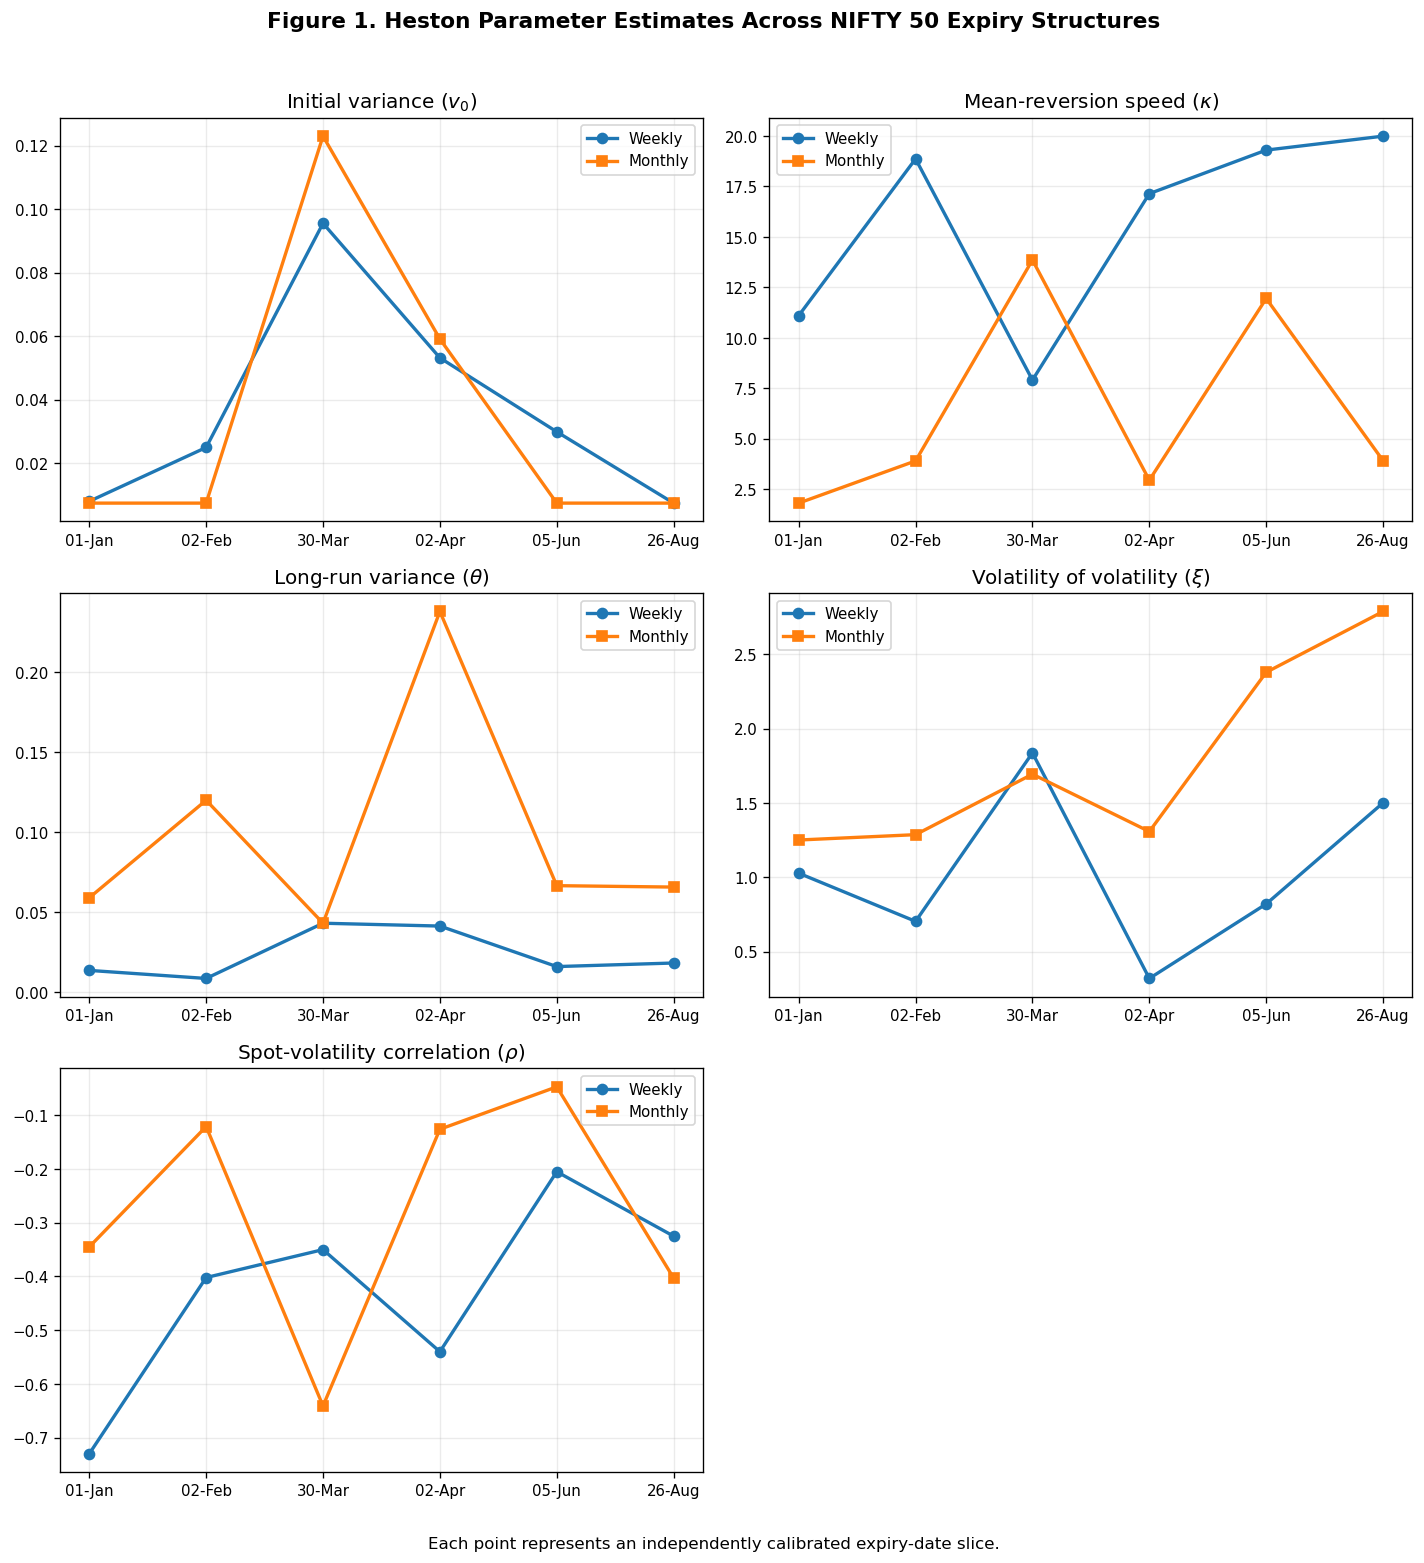

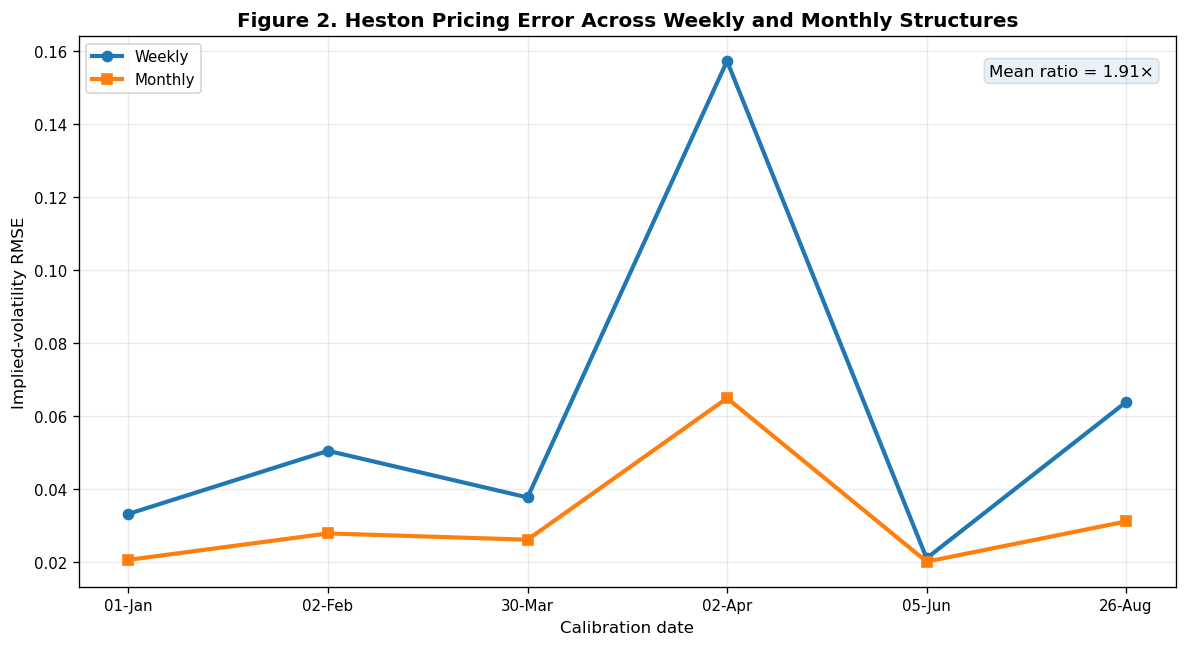

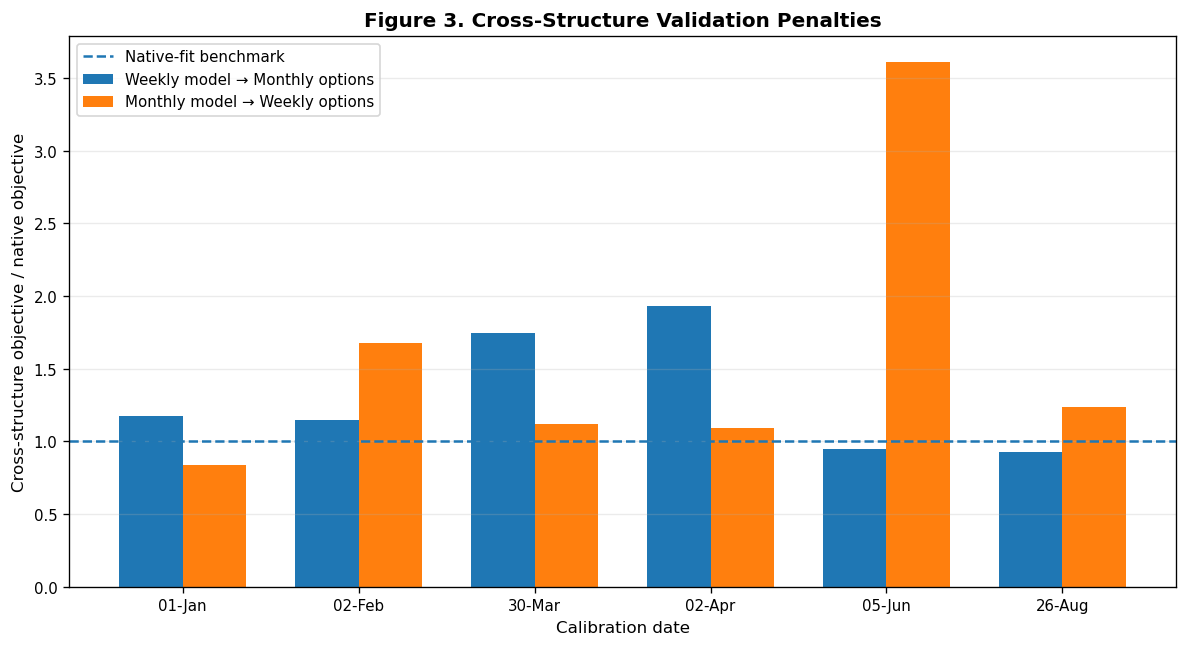

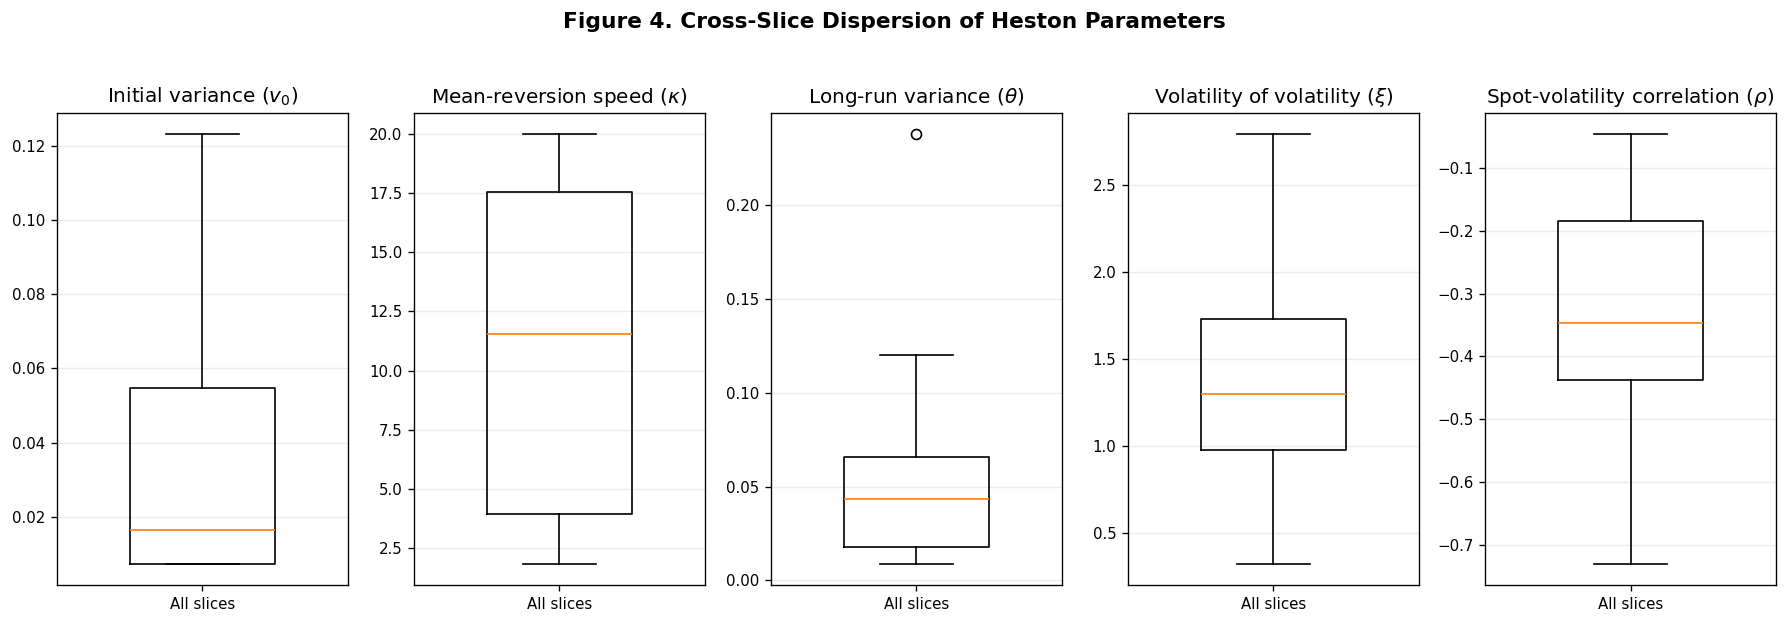

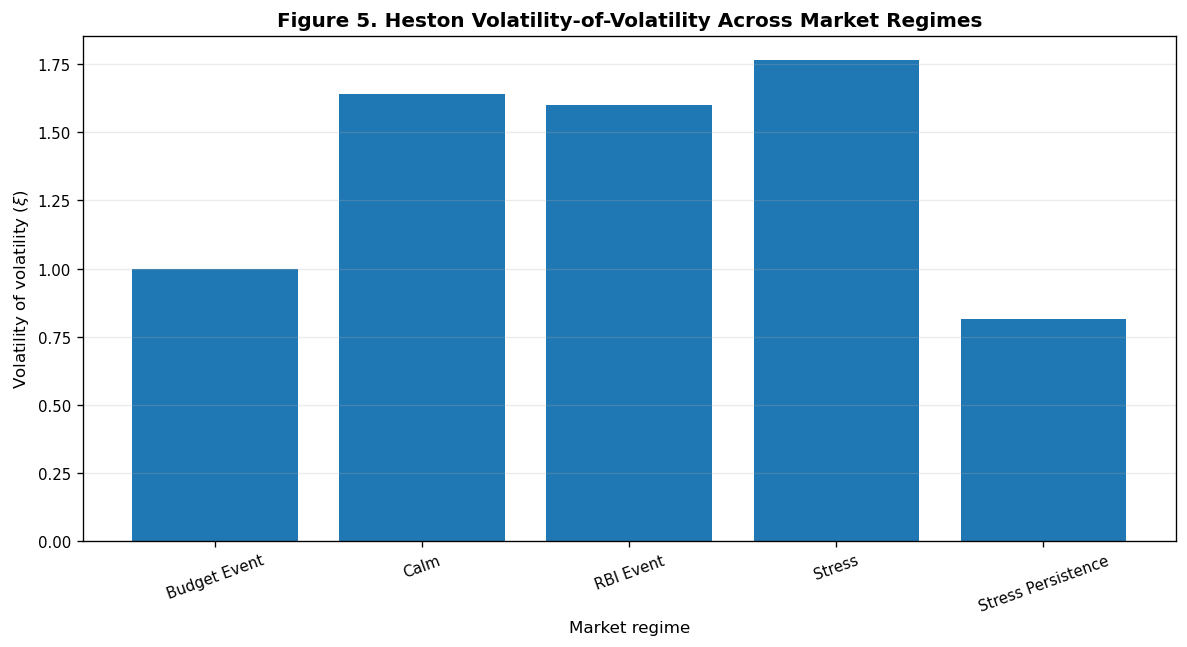

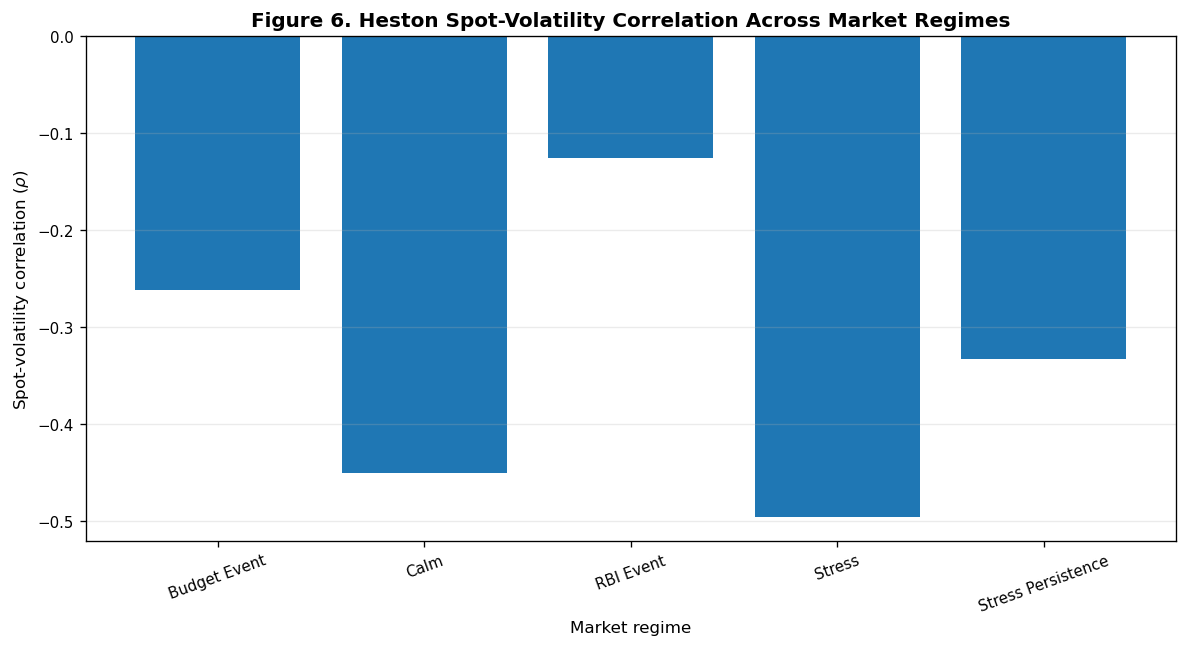

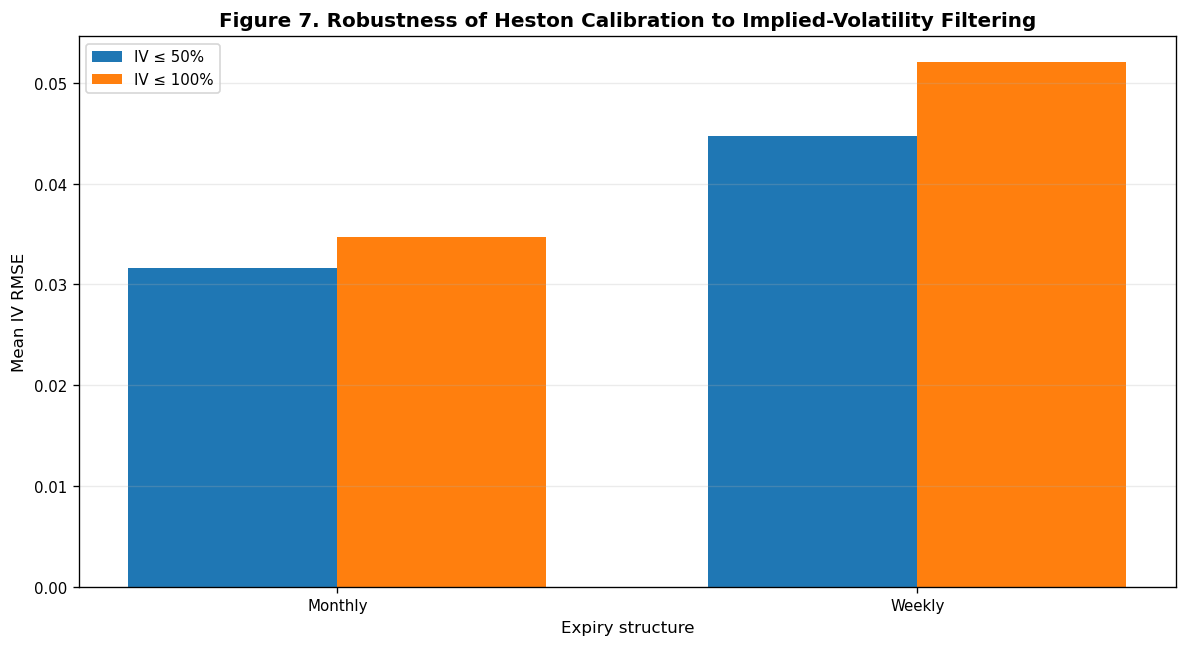

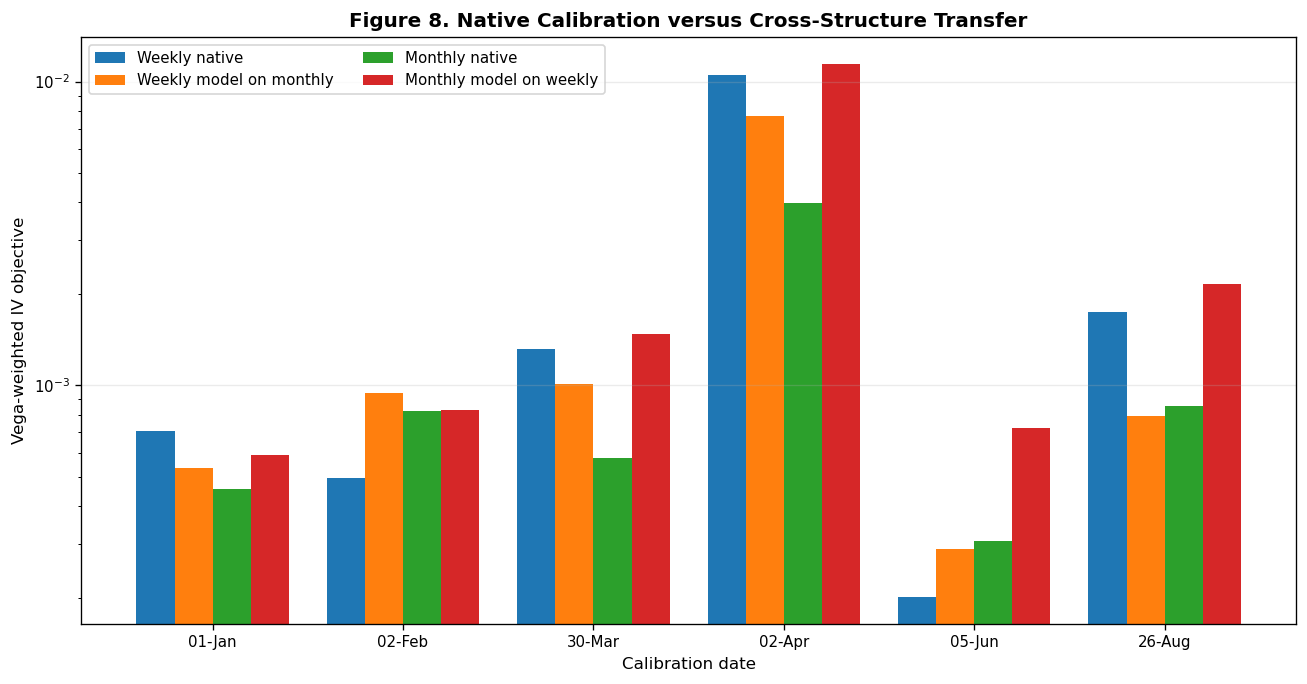


PAPER FIGURES GENERATED
✓ Figure_1_Parameter_Stability.png
✓ Figure_2_Weekly_Monthly_RMSE.png
✓ Figure_3_Cross_Structure_Validation.png
✓ Figure_4_Parameter_Dispersion.png
✓ Figure_5_Regime_Xi.png
✓ Figure_6_Regime_Rho.png
✓ Figure_7_IV_Robustness.png
✓ Figure_8_Native_vs_Transferred.png

Key empirical values used:
Weekly mean IV RMSE       : 0.060583
Monthly mean IV RMSE      : 0.031780
Weekly / Monthly RMSE     : 1.906x
Weekly → Monthly penalty  : 1.312x
Monthly → Weekly penalty  : 1.596x
Mean Xi                   : 1.036 weekly / 1.786 monthly
Mean Rho                  : -0.425 weekly / -0.281 monthly

All figures saved at 600 DPI in:
/Users/shakthivel2211gmail.com/Documents/NIFTY DATA/Heston_Paper_Figures


In [16]:
# =============================================================================
# PAPER FIGURES
# HESTON-NIFTY 50: ROBUSTNESS & VALIDATION VISUAL EVIDENCE
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------------------------------------------------
# GLOBAL PAPER STYLE
# -------------------------------------------------------------------------

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 13
})

FIG_DIR = Path("Heston_Paper_Figures")
FIG_DIR.mkdir(exist_ok=True)

# =============================================================================
# DATA FROM MASTER VALIDATION OUTPUT
# =============================================================================

dates = [
    "01-Jan", "02-Feb", "30-Mar",
    "02-Apr", "05-Jun", "26-Aug"
]

# -------------------------------------------------------------------------
# 1. WEEKLY VS MONTHLY HESTON PARAMETERS
# -------------------------------------------------------------------------

weekly = pd.DataFrame({
    "Date": dates,
    "v0":    [0.00793, 0.02490, 0.09555, 0.05314, 0.02984, 0.00736],
    "kappa": [11.104, 18.866, 7.913, 17.144, 19.300, 19.991],
    "theta": [0.01376, 0.00874, 0.04321, 0.04144, 0.01615, 0.01838],
    "xi":    [1.029, 0.705, 1.838, 0.321, 0.822, 1.502],
    "rho":   [-0.730, -0.402, -0.350, -0.540, -0.205, -0.325]
})

monthly = pd.DataFrame({
    "Date": dates,
    "v0":    [0.00736, 0.00736, 0.12301, 0.05909, 0.00736, 0.00736],
    "kappa": [1.820, 3.910, 13.859, 2.956, 11.952, 3.921],
    "theta": [0.05909, 0.11996, 0.04322, 0.23777, 0.06665, 0.06577],
    "xi":    [1.252, 1.288, 1.695, 1.309, 2.380, 2.789],
    "rho":   [-0.345, -0.121, -0.641, -0.126, -0.047, -0.403]
})

# -------------------------------------------------------------------------
# 2. RMSE
# -------------------------------------------------------------------------

weekly_rmse = np.array([
    0.03319, 0.05047, 0.03770,
    0.15726, 0.02104, 0.06384
])

monthly_rmse = np.array([
    0.02060, 0.02784, 0.02612,
    0.06489, 0.02011, 0.03112
])

# -------------------------------------------------------------------------
# 3. CROSS-STRUCTURE VALIDATION
# -------------------------------------------------------------------------

weekly_native = np.array([
    0.000705, 0.000496, 0.001319,
    0.010478, 0.000201, 0.001738
])

monthly_native = np.array([
    0.000455, 0.000824, 0.000576,
    0.003973, 0.000307, 0.000856
])

weekly_on_monthly = np.array([
    0.000534, 0.000943, 0.001007,
    0.007685, 0.000290, 0.000792
])

monthly_on_weekly = np.array([
    0.000592, 0.000832, 0.001481,
    0.011457, 0.000725, 0.002149
])

weekly_cross_penalty = np.array([
    1.172716, 1.144747, 1.747622,
    1.934532, 0.944626, 0.925156
])

monthly_cross_penalty = np.array([
    0.839865, 1.676763, 1.122542,
    1.093476, 3.609070, 1.236280
])

# -------------------------------------------------------------------------
# 4. REGIME DATA
# -------------------------------------------------------------------------

regime_data = pd.DataFrame({
    "Regime": [
        "Budget Event",
        "Calm",
        "RBI Event",
        "Stress",
        "Stress Persistence"
    ],
    "v0": [0.016131, 0.007502, 0.018600, 0.109283, 0.056115],
    "kappa": [11.387744, 9.208973, 15.626062, 10.886071, 10.050114],
    "theta": [0.064353, 0.039251, 0.041401, 0.043218, 0.139606],
    "xi": [0.996606, 1.642961, 1.600899, 1.766169, 0.814990],
    "rho": [-0.261319, -0.450775, -0.125988, -0.495319, -0.332930],
    "RMSE": [0.039153, 0.037185, 0.020576, 0.031906, 0.111075]
})

# -------------------------------------------------------------------------
# 5. ROBUSTNESS DATA
# -------------------------------------------------------------------------

robustness = pd.DataFrame({
    "Date": dates,
    "Monthly_50": [0.028794, 0.028586, 0.026113, 0.046620, 0.021983, 0.037606],
    "Weekly_50":  [0.054667, 0.025306, 0.036753, 0.059022, 0.017768, 0.074720],
    "Monthly_100": [0.028794, 0.028586, 0.026113, 0.064892, 0.021983, 0.037606],
    "Weekly_100":  [0.054667, 0.029194, 0.036753, 0.098476, 0.017768, 0.075384]
})

# =============================================================================
# FIGURE 1
# WEEKLY VS MONTHLY PARAMETERIZATION
# =============================================================================

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
axes = axes.flatten()

parameters = [
    ("v0", "Initial variance ($v_0$)"),
    ("kappa", "Mean-reversion speed ($\\kappa$)"),
    ("theta", "Long-run variance ($\\theta$)"),
    ("xi", "Volatility of volatility ($\\xi$)"),
    ("rho", "Spot-volatility correlation ($\\rho$)")
]

x = np.arange(len(dates))

for ax, (param, label) in zip(axes, parameters):

    ax.plot(
        x, weekly[param],
        marker="o",
        linewidth=2,
        label="Weekly"
    )

    ax.plot(
        x, monthly[param],
        marker="s",
        linewidth=2,
        label="Monthly"
    )

    ax.set_title(label)
    ax.set_xticks(x)
    ax.set_xticklabels(dates)
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].axis("off")

fig.suptitle(
    "Figure 1. Heston Parameter Estimates Across NIFTY 50 Expiry Structures",
    fontweight="bold",
    y=0.995
)

fig.text(
    0.5, 0.01,
    "Each point represents an independently calibrated expiry-date slice.",
    ha="center"
)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])

plt.savefig(
    FIG_DIR / "Figure_1_Parameter_Stability.png",
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# FIGURE 2
# WEEKLY VS MONTHLY RMSE
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    x, weekly_rmse,
    marker="o",
    linewidth=2.5,
    label="Weekly"
)

ax.plot(
    x, monthly_rmse,
    marker="s",
    linewidth=2.5,
    label="Monthly"
)

ax.set_xticks(x)
ax.set_xticklabels(dates)

ax.set_ylabel("Implied-volatility RMSE")
ax.set_xlabel("Calibration date")

ax.set_title(
    "Figure 2. Heston Pricing Error Across Weekly and Monthly Structures",
    fontweight="bold"
)

ax.grid(alpha=0.25)
ax.legend()

ax.text(
    0.98, 0.95,
    f"Mean ratio = {weekly_rmse.mean()/monthly_rmse.mean():.2f}×",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.1)
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "Figure_2_Weekly_Monthly_RMSE.png",
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# FIGURE 3
# CROSS-STRUCTURE VALIDATION PENALTIES
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

width = 0.36

x_bar = np.arange(len(dates))

ax.bar(
    x_bar - width/2,
    weekly_cross_penalty,
    width,
    label="Weekly model → Monthly options"
)

ax.bar(
    x_bar + width/2,
    monthly_cross_penalty,
    width,
    label="Monthly model → Weekly options"
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    label="Native-fit benchmark"
)

ax.set_xticks(x_bar)
ax.set_xticklabels(dates)

ax.set_ylabel("Cross-structure objective / native objective")
ax.set_xlabel("Calibration date")

ax.set_title(
    "Figure 3. Cross-Structure Validation Penalties",
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "Figure_3_Cross_Structure_Validation.png",
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# FIGURE 4
# PARAMETER DISPERSION
# =============================================================================

fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for ax, (param, label) in zip(axes, parameters):

    combined = np.concatenate([
        weekly[param].values,
        monthly[param].values
    ])

    ax.boxplot(
        combined,
        widths=0.5
    )

    ax.set_title(label)

    ax.set_xticks([1])
    ax.set_xticklabels(["All slices"])

    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Figure 4. Cross-Slice Dispersion of Heston Parameters",
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "Figure_4_Parameter_Dispersion.png",
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# FIGURE 5
# REGIME COMPARISON: XI
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(
    regime_data["Regime"],
    regime_data["xi"]
)

ax.set_ylabel("Volatility of volatility ($\\xi$)")
ax.set_xlabel("Market regime")

ax.set_title(
    "Figure 5. Heston Volatility-of-Volatility Across Market Regimes",
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "Figure_5_Regime_Xi.png",
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# FIGURE 6
# REGIME COMPARISON: RHO
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(
    regime_data["Regime"],
    regime_data["rho"]
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_ylabel("Spot-volatility correlation ($\\rho$)")
ax.set_xlabel("Market regime")

ax.set_title(
    "Figure 6. Heston Spot-Volatility Correlation Across Market Regimes",
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "Figure_6_Regime_Rho.png",
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# FIGURE 7
# IV ROBUSTNESS
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

robust_mean_50 = [
    robustness["Monthly_50"].mean(),
    robustness["Weekly_50"].mean()
]

robust_mean_100 = [
    robustness["Monthly_100"].mean(),
    robustness["Weekly_100"].mean()
]

structures = ["Monthly", "Weekly"]

x_bar = np.arange(len(structures))
width = 0.36

ax.bar(
    x_bar - width/2,
    robust_mean_50,
    width,
    label="IV ≤ 50%"
)

ax.bar(
    x_bar + width/2,
    robust_mean_100,
    width,
    label="IV ≤ 100%"
)

ax.set_xticks(x_bar)
ax.set_xticklabels(structures)

ax.set_ylabel("Mean IV RMSE")
ax.set_xlabel("Expiry structure")

ax.set_title(
    "Figure 7. Robustness of Heston Calibration to Implied-Volatility Filtering",
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "Figure_7_IV_Robustness.png",
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# FIGURE 8
# CROSS-STRUCTURE NATIVE VS TRANSFERRED OBJECTIVES
# =============================================================================

fig, ax = plt.subplots(figsize=(11, 5.8))

labels = dates

x8 = np.arange(len(labels))
width8 = 0.2

ax.bar(
    x8 - 1.5*width8,
    weekly_native,
    width8,
    label="Weekly native"
)

ax.bar(
    x8 - 0.5*width8,
    weekly_on_monthly,
    width8,
    label="Weekly model on monthly"
)

ax.bar(
    x8 + 0.5*width8,
    monthly_native,
    width8,
    label="Monthly native"
)

ax.bar(
    x8 + 1.5*width8,
    monthly_on_weekly,
    width8,
    label="Monthly model on weekly"
)

ax.set_xticks(x8)
ax.set_xticklabels(labels)

ax.set_ylabel("Vega-weighted IV objective")
ax.set_xlabel("Calibration date")

ax.set_title(
    "Figure 8. Native Calibration versus Cross-Structure Transfer",
    fontweight="bold"
)

ax.set_yscale("log")

ax.grid(axis="y", alpha=0.25)
ax.legend(ncol=2)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "Figure_8_Native_vs_Transferred.png",
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# MASTER SUMMARY
# =============================================================================

print("\n" + "="*80)
print("PAPER FIGURES GENERATED")
print("="*80)

for f in sorted(FIG_DIR.glob("*.png")):
    print(f"✓ {f.name}")

print("\nKey empirical values used:")
print(f"Weekly mean IV RMSE       : {weekly_rmse.mean():.6f}")
print(f"Monthly mean IV RMSE      : {monthly_rmse.mean():.6f}")
print(f"Weekly / Monthly RMSE     : {weekly_rmse.mean()/monthly_rmse.mean():.3f}x")
print(f"Weekly → Monthly penalty  : {weekly_cross_penalty.mean():.3f}x")
print(f"Monthly → Weekly penalty  : {monthly_cross_penalty.mean():.3f}x")
print(f"Mean Xi                   : {weekly['xi'].mean():.3f} weekly / {monthly['xi'].mean():.3f} monthly")
print(f"Mean Rho                  : {weekly['rho'].mean():.3f} weekly / {monthly['rho'].mean():.3f} monthly")

print("\nAll figures saved at 600 DPI in:")
print(FIG_DIR.resolve())

## 14. Results to report

The notebook reports:
1. The exact January calibration universe and CE/PE split.
2. The verified Phase-1 Heston benchmark.
3. Differential Evolution and Powell candidate parameters.
4. Full-sample objective values for each candidate.
5. Final adaptive Fourier objective, IV RMSE and IV MAE.
6. Feller condition as a diagnostic only.
7. Fourier convergence counts and selected upper bounds.
8. Option-type residual diagnostics.
9. Market-IV versus model-IV and residual plots.

The current V6 calibration universe is based on the executed 449-row January dataset. The previously observed 388-row V5.1 universe is retained as a historical implementation checkpoint, not silently substituted into the current results.
